<a href="https://colab.research.google.com/github/DancesWChickens/DBSA-UTAustin/blob/main/ModelTuning_ReneWind_FullCode_Ebricker_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
#!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 imbalanced-learn==0.10.1 xgboost==2.0.3 threadpoolctl==3.3.0 -q --user

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn import metrics

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# convert ipnb to HTML file
%cd /content/drive/MyDrive/Colab\ Notebooks


!jupyter nbconvert MT_Project_LearnerNotebook_FullCode_Ebricker_Final.ipynb --to html


/content/drive/MyDrive/Colab Notebooks
[NbConvertApp] Converting notebook MT_Project_LearnerNotebook_FullCode_Ebricker_Final.ipynb to html
[NbConvertApp] Writing 4085055 bytes to MT_Project_LearnerNotebook_FullCode_Ebricker_Final.html


## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


# read the dataset
df_train=pd.read_csv('/content/drive/My Drive/UTAustinDataScience/datafiles/ModelTuningTrain.csv')
df_test=pd.read_csv('/content/drive/My Drive/UTAustinDataScience/datafiles/ModelTuningTest.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

- Observations
- Sanity checks

In [ ]:
#check the shape of the data
df_train.shape

(20000, 41)

### Observation
There are 20,000 rows and 41 columns in the train set.

In [ ]:
df_test.shape

(5000, 41)

### Observation
There are 5,000 rows and 41 columns in the train set.

In [ ]:
#check columns and datatypes
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

###Observation
Just looking at the counts, even though the columns are all set to non-null, I can see that V1 and V2 have fewer values than all the other variables.

All columns are of type float64, so there are no categorical variables.

In [ ]:
df_train.duplicated().sum()

0

In [ ]:
df_test.duplicated().sum()

0

###Observation
There are no duplicate values in either data set.

In [ ]:
df_train.isna().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
df_test.isna().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


### Observation
There are 18 "N/A" values in both V1 and V2 in the train set
In the test set, there are 5 and 6 missing values for V1 and V2 in the train and test set, respectively.

In [ ]:
df_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.465,-4.679,3.102,0.506,-0.221,-2.033,-2.911,0.051,-1.522,3.762,-5.715,0.736,0.981,1.418,-3.376,-3.047,0.306,2.914,2.270,4.395,-2.388,0.646,-1.191,3.133,0.665,-2.511,-0.037,0.726,-3.982,-1.073,1.667,3.060,-1.690,2.846,2.235,6.667,0.444,-2.369,2.951,-3.480,0
1,3.366,3.653,0.910,-1.368,0.332,2.359,0.733,-4.332,0.566,-0.101,1.914,-0.951,-1.255,-2.707,0.193,-4.769,-2.205,0.908,0.757,-5.834,-3.065,1.597,-1.757,1.766,-0.267,3.625,1.500,-0.586,0.783,-0.201,0.025,-1.795,3.033,-2.468,1.895,-2.298,-1.731,5.909,-0.386,0.616,0
2,-3.832,-5.824,0.634,-2.419,-1.774,1.017,-2.099,-3.173,-2.082,5.393,-0.771,1.107,1.144,0.943,-3.164,-4.248,-4.039,3.689,3.311,1.059,-2.143,1.650,-1.661,1.680,-0.451,-4.551,3.739,1.134,-2.034,0.841,-1.600,-0.257,0.804,4.086,2.292,5.361,0.352,2.940,3.839,-4.309,0
3,1.618,1.888,7.046,-1.147,0.083,-1.530,0.207,-2.494,0.345,2.119,-3.053,0.460,2.705,-0.636,-0.454,-3.174,-3.404,-1.282,1.582,-1.952,-3.517,-1.206,-5.628,-1.818,2.124,5.295,4.748,-2.309,-3.963,-6.029,4.949,-3.584,-2.577,1.364,0.623,5.550,-1.527,0.139,3.101,-1.277,0
4,-0.111,3.872,-3.758,-2.983,3.793,0.545,0.205,4.849,-1.855,-6.220,1.998,4.724,0.709,-1.989,-2.633,4.184,2.245,3.734,-6.313,-5.380,-0.887,2.062,9.446,4.490,-3.945,4.582,-8.780,-3.383,5.107,6.788,2.044,8.266,6.629,-10.069,1.223,-3.230,1.687,-2.164,-3.645,6.510,0


In [ ]:
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613,-3.820,2.202,1.300,-1.185,-4.496,-1.836,4.723,1.206,-0.342,-5.123,1.017,4.819,3.269,-2.984,1.387,2.032,-0.512,-1.023,7.339,-2.242,0.155,2.054,-2.772,1.851,-1.789,-0.277,-1.255,-3.833,-1.505,1.587,2.291,-5.411,0.870,0.574,4.157,1.428,-10.511,0.455,-1.448,0
1,0.390,-0.512,0.527,-2.577,-1.017,2.235,-0.441,-4.406,-0.333,1.967,1.797,0.410,0.638,-1.390,-1.883,-5.018,-3.827,2.418,1.762,-3.242,-3.193,1.857,-1.708,0.633,-0.588,0.084,3.014,-0.182,0.224,0.865,-1.782,-2.475,2.494,0.315,2.059,0.684,-0.485,5.128,1.721,-1.488,0
2,-0.875,-0.641,4.084,-1.590,0.526,-1.958,-0.695,1.347,-1.732,0.466,-4.928,3.565,-0.449,-0.656,-0.167,-1.630,2.292,2.396,0.601,1.794,-2.120,0.482,-0.841,1.790,1.874,0.364,-0.169,-0.484,-2.119,-2.157,2.907,-1.319,-2.997,0.460,0.620,5.632,1.324,-1.752,1.808,1.676,0
3,0.238,1.459,4.015,2.534,1.197,-3.117,-0.924,0.269,1.322,0.702,-5.578,-0.851,2.591,0.767,-2.391,-2.342,0.572,-0.934,0.509,1.211,-3.260,0.105,-0.659,1.498,1.100,4.143,-0.248,-1.137,-5.356,-4.546,3.809,3.518,-3.074,-0.284,0.955,3.029,-1.367,-3.412,0.906,-2.451,0
4,5.828,2.768,-1.235,2.809,-1.642,-1.407,0.569,0.965,1.918,-2.775,-0.530,1.375,-0.651,-1.679,-0.379,-4.443,3.894,-0.608,2.945,0.367,-5.789,4.598,4.450,3.225,0.397,0.248,-2.362,1.079,-0.473,2.243,-3.591,1.774,-1.502,-2.227,4.777,-6.560,-0.806,-0.276,-3.858,-0.538,0


In [ ]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.000,-0.272,3.442,-11.876,-2.737,-0.748,1.840,15.493
V2,19982.000,0.440,3.151,-12.320,-1.641,0.472,2.544,13.089
V3,20000.000,2.485,3.389,-10.708,0.207,2.256,4.566,17.091
V4,20000.000,-0.083,3.432,-15.082,-2.348,-0.135,2.131,13.236
V5,20000.000,-0.054,2.105,-8.603,-1.536,-0.102,1.340,8.134
V6,20000.000,-0.995,2.041,-10.227,-2.347,-1.001,0.380,6.976
V7,20000.000,-0.879,1.762,-7.950,-2.031,-0.917,0.224,8.006
V8,20000.000,-0.548,3.296,-15.658,-2.643,-0.389,1.723,11.679
V9,20000.000,-0.017,2.161,-8.596,-1.495,-0.068,1.409,8.138
V10,20000.000,-0.013,2.193,-9.854,-1.411,0.101,1.477,8.108


#### Observation
All variables are numerical and continuous.

### Making a copy of the data

In [ ]:
data_train=df_train.copy()

In [ ]:
data_test=df_test.copy()

## Exploratory Data Analysis (EDA)

### Plotting histograms and boxplots for all the variables

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Plotting All the Features at Once!

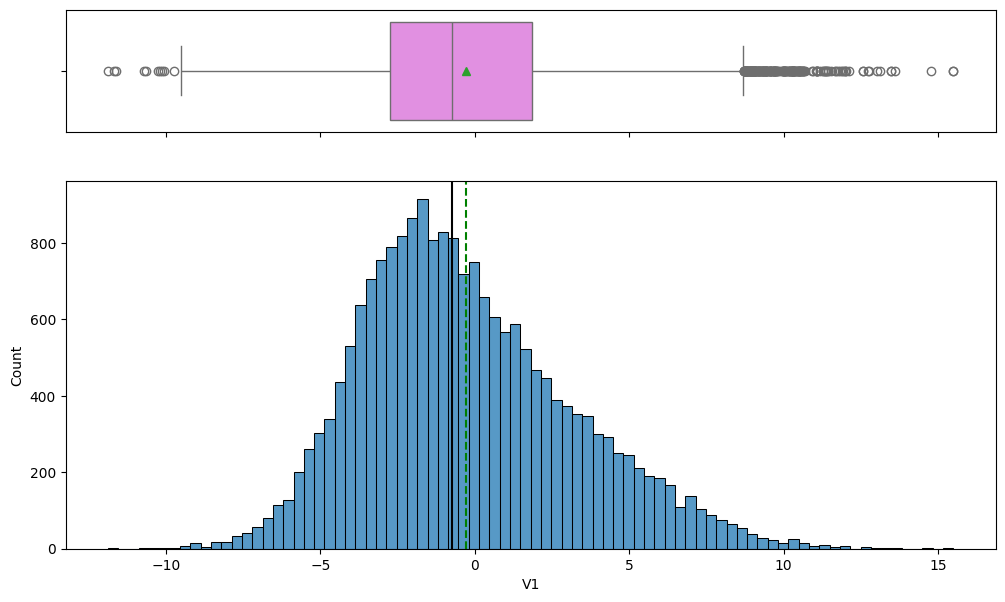

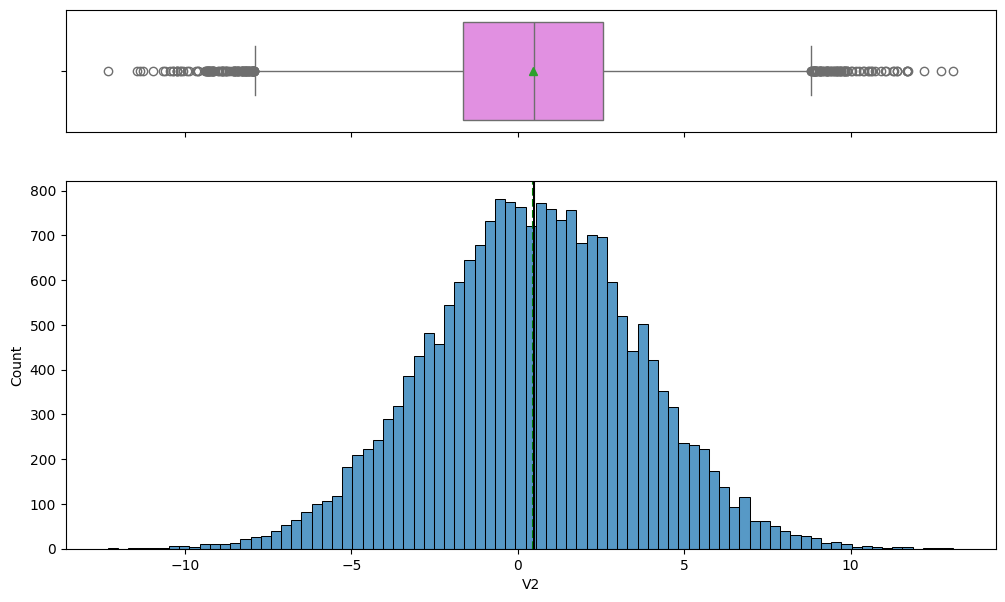

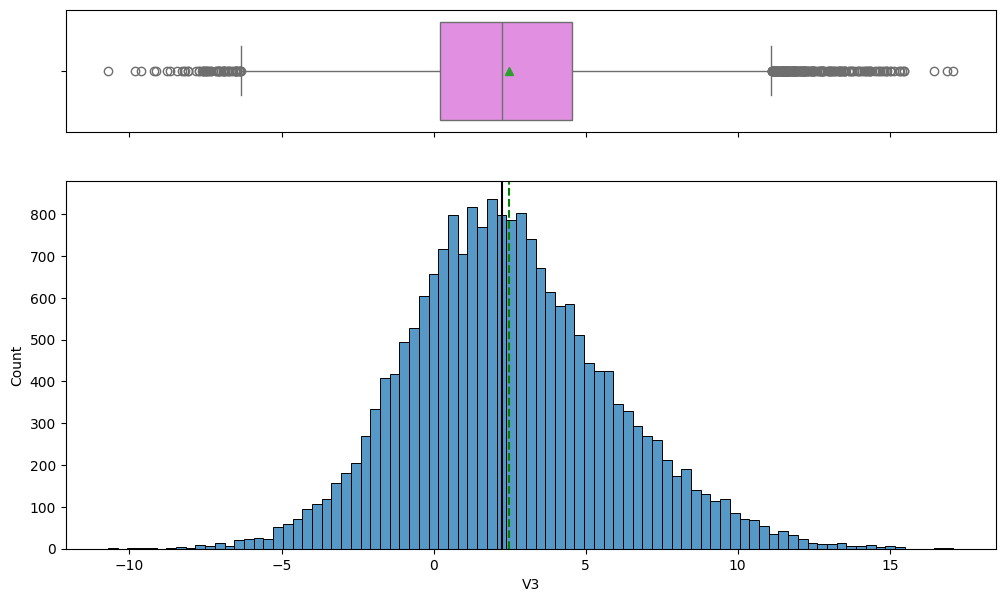

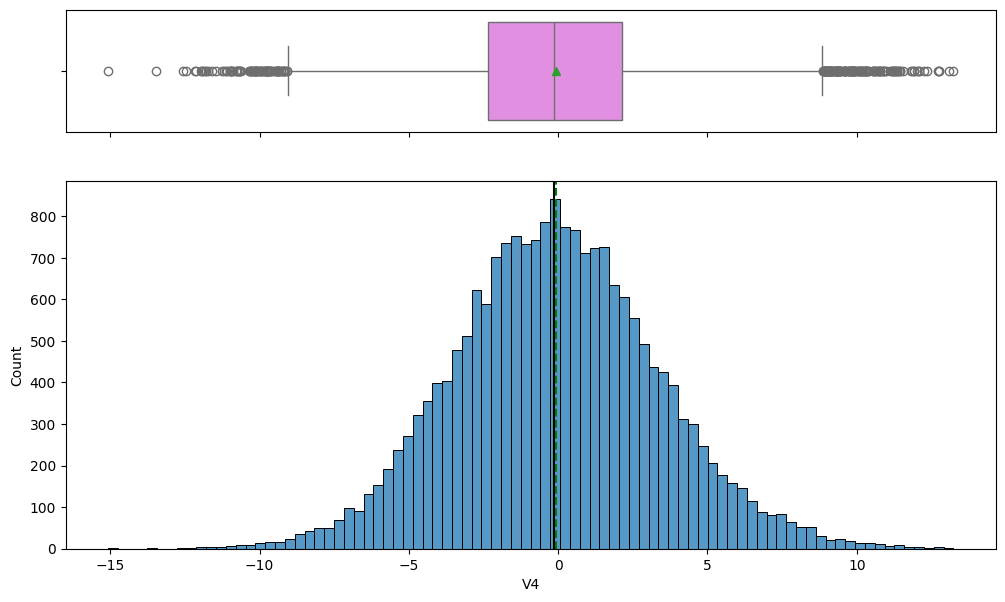

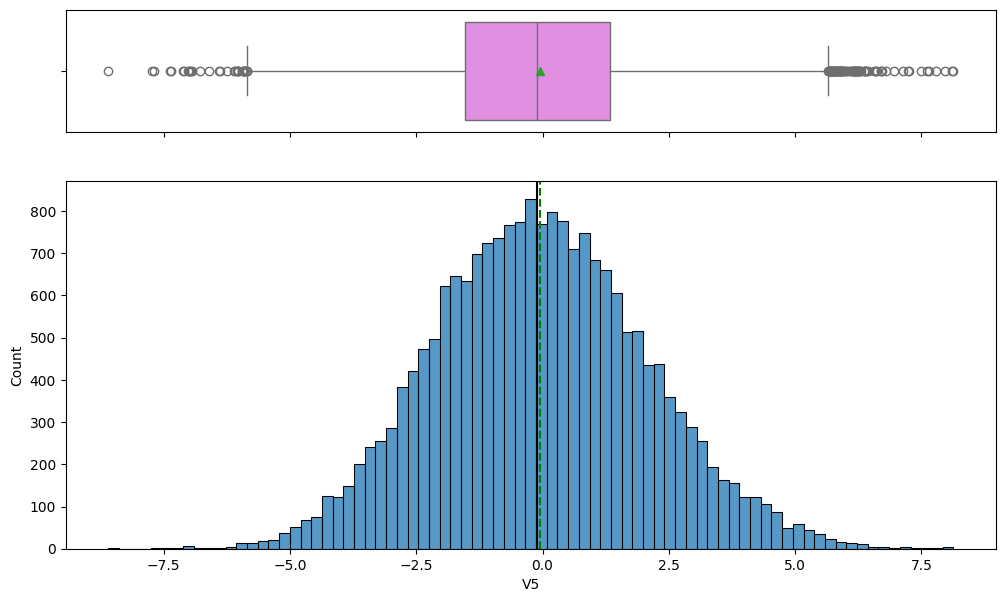

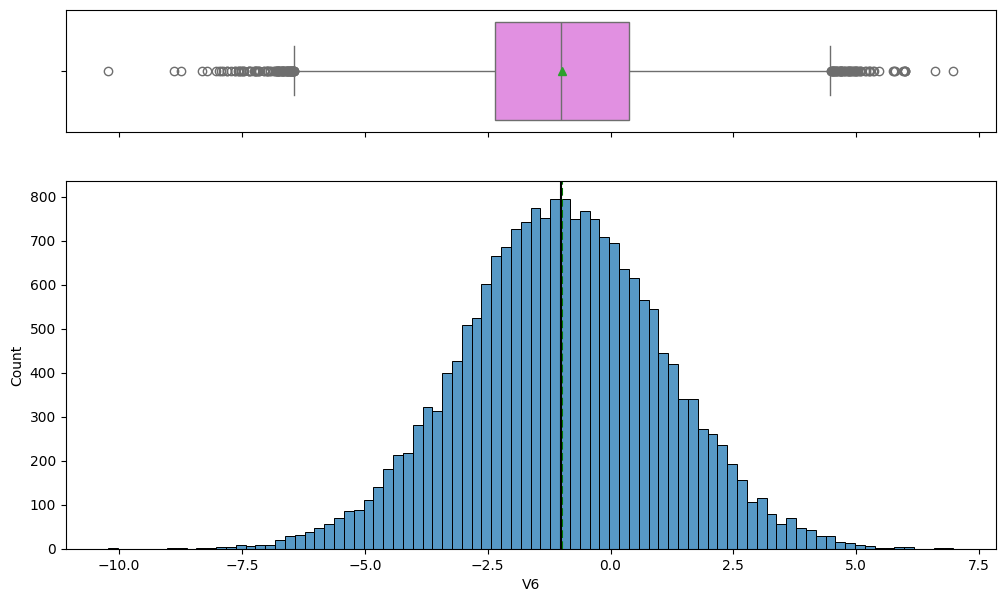

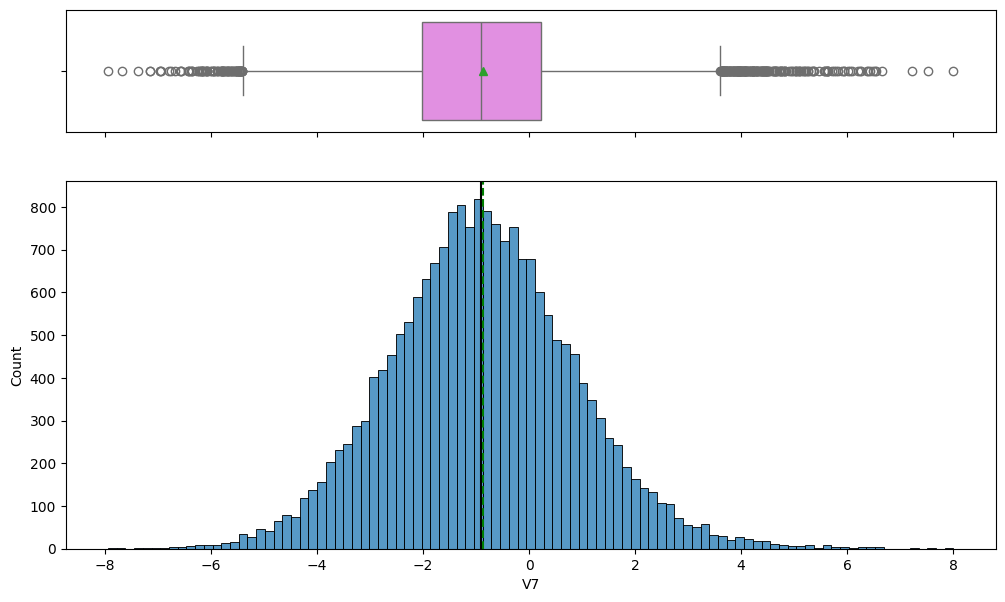

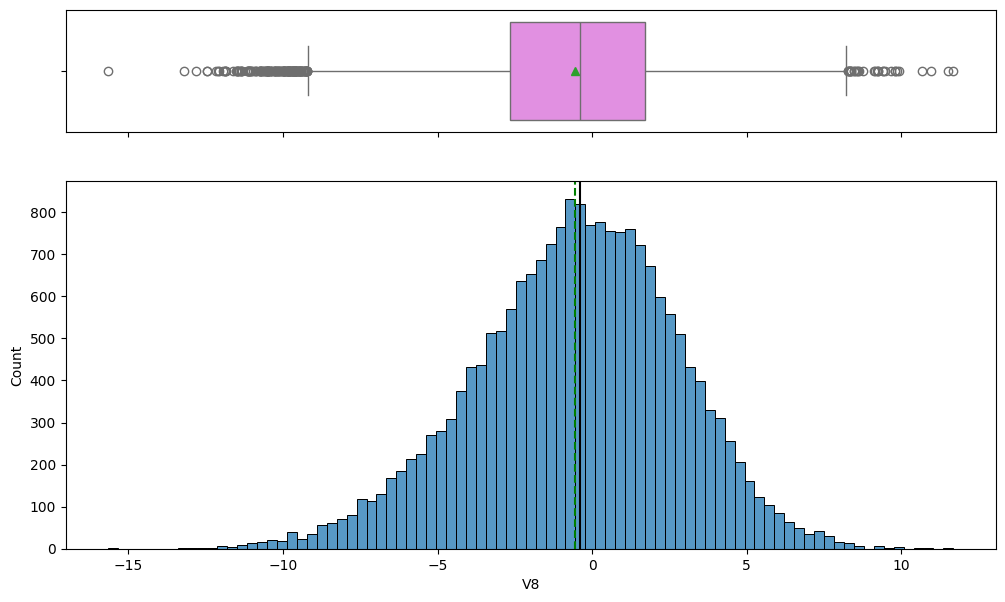

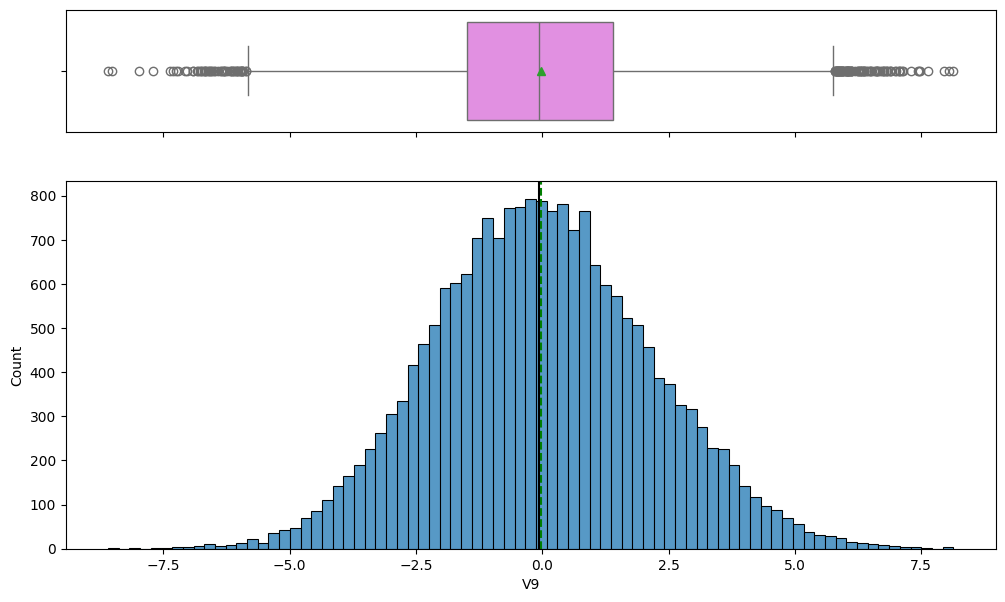

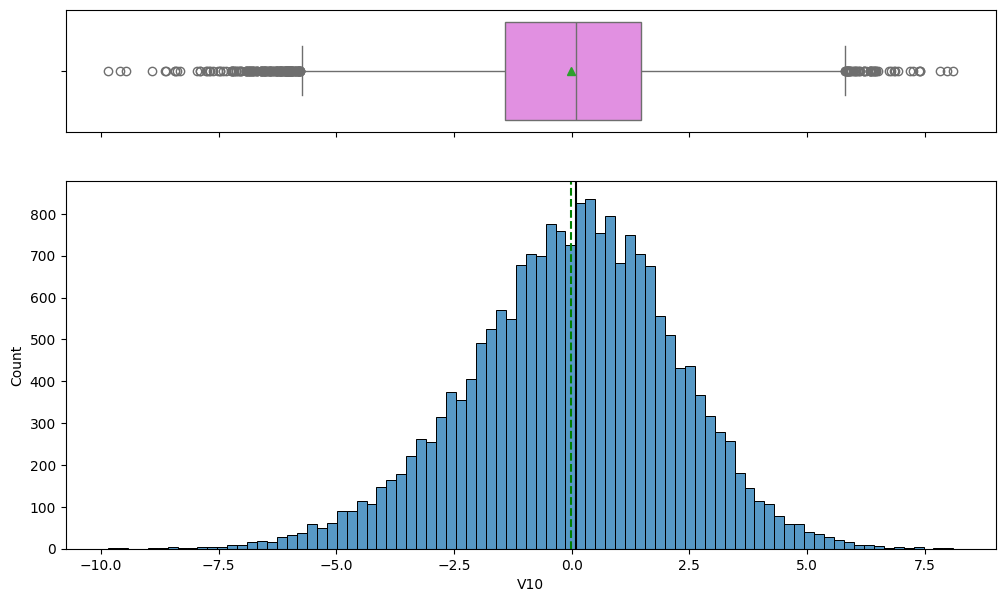

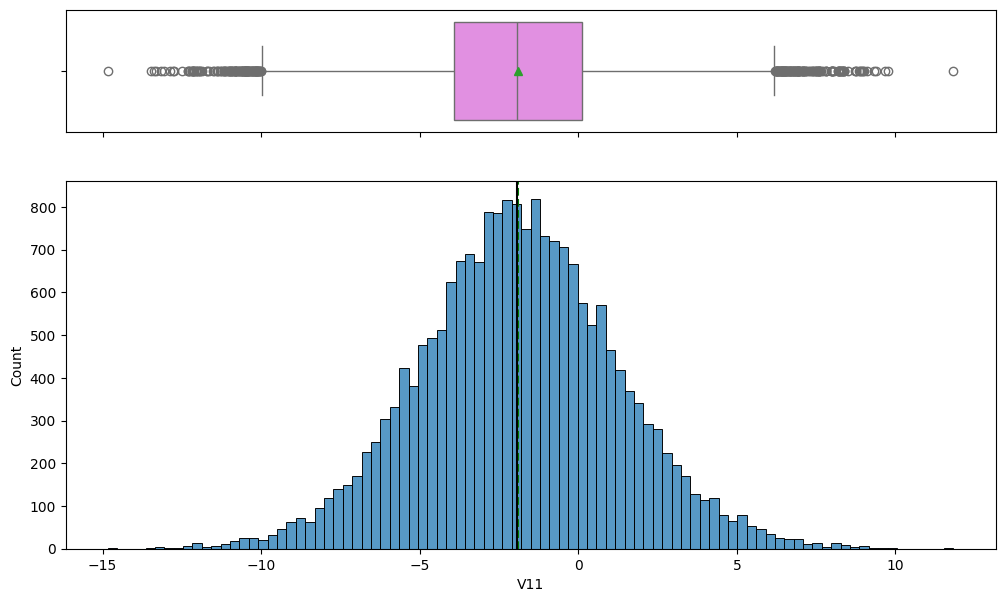

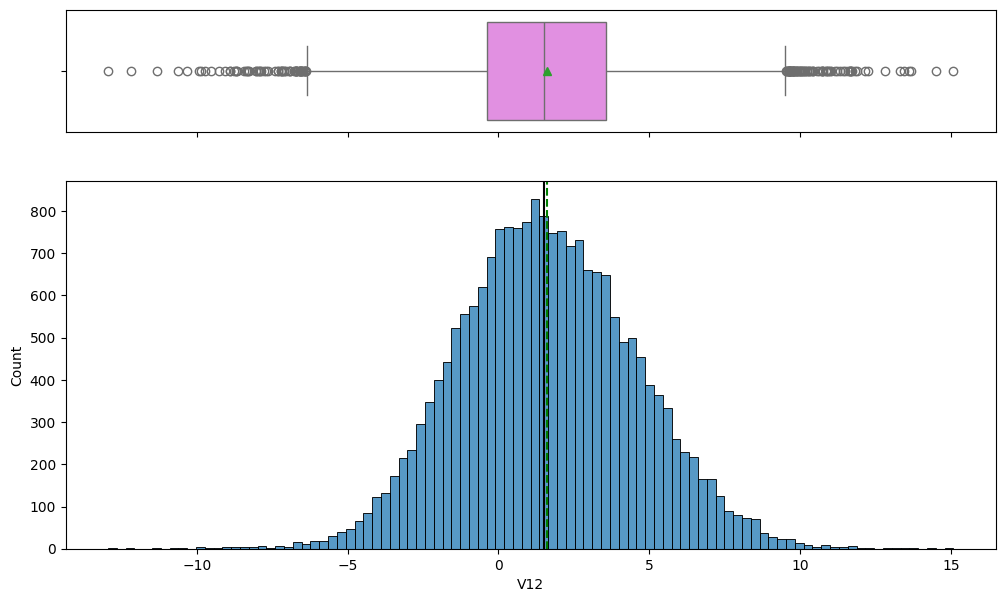

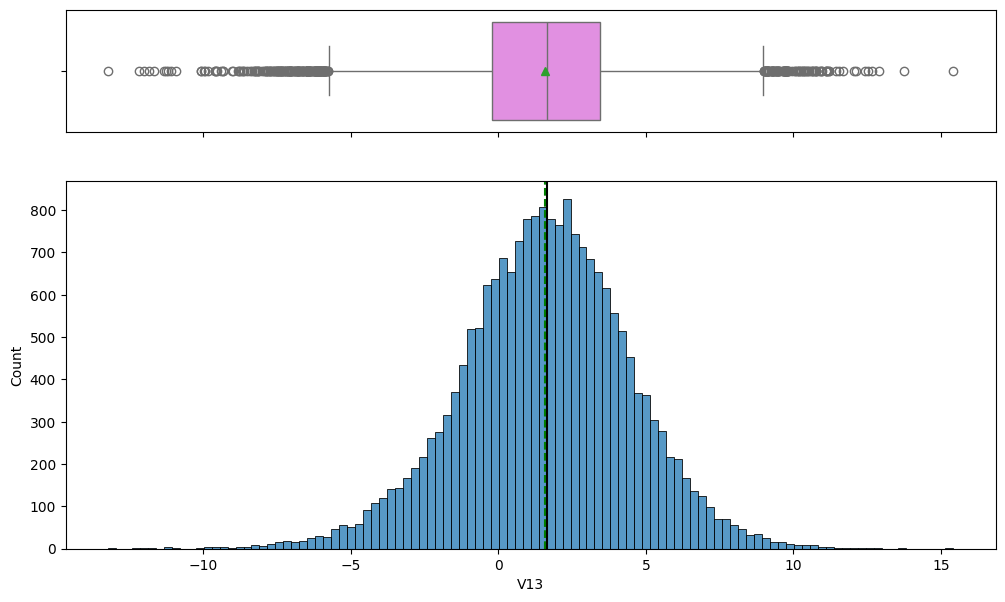

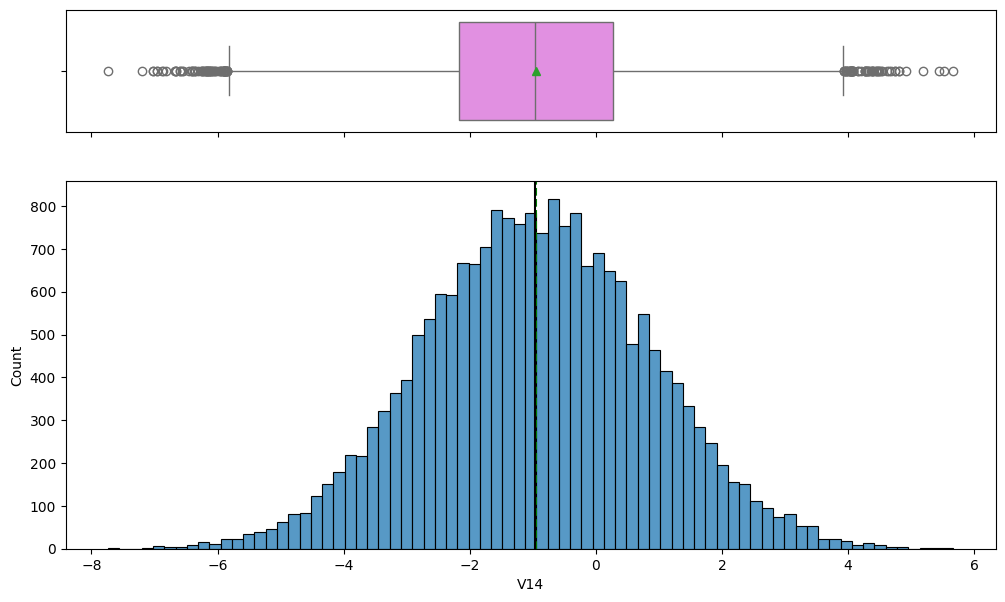

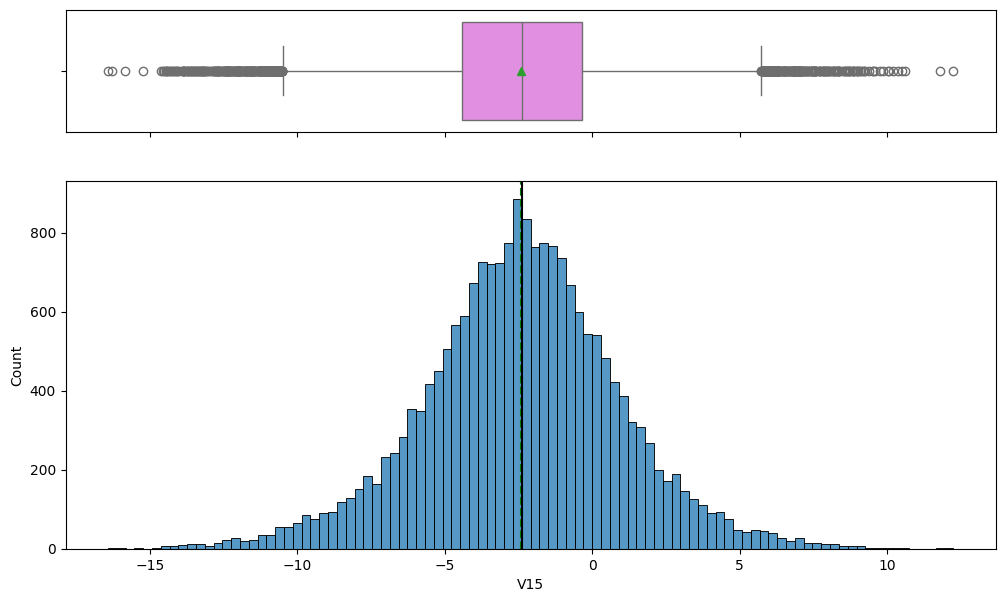

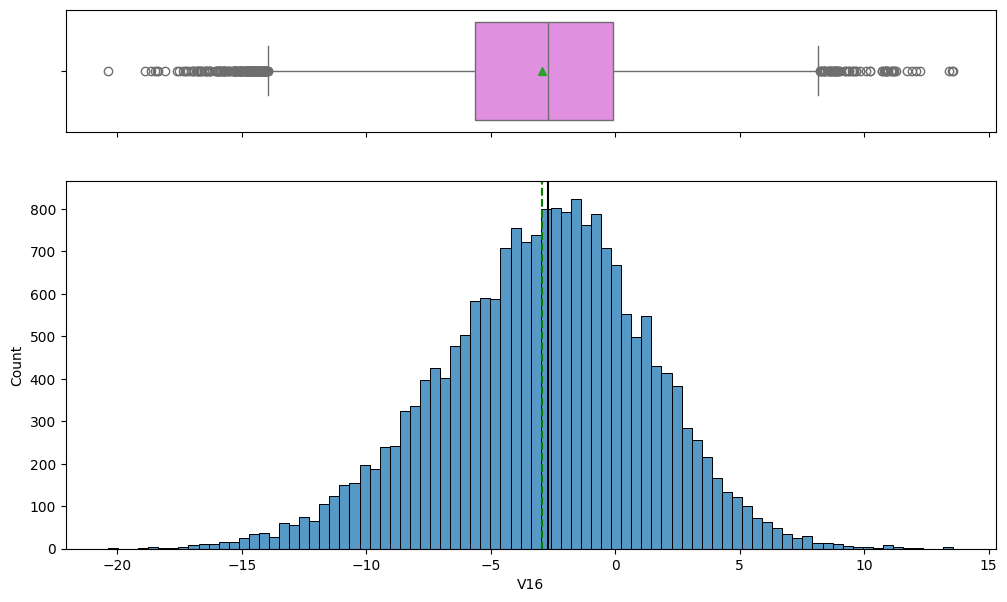

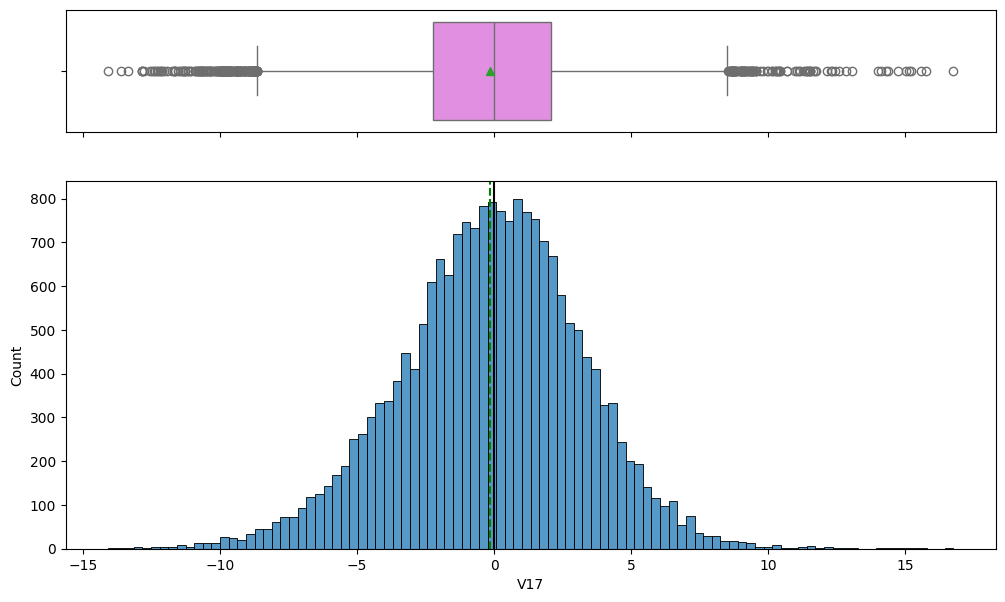

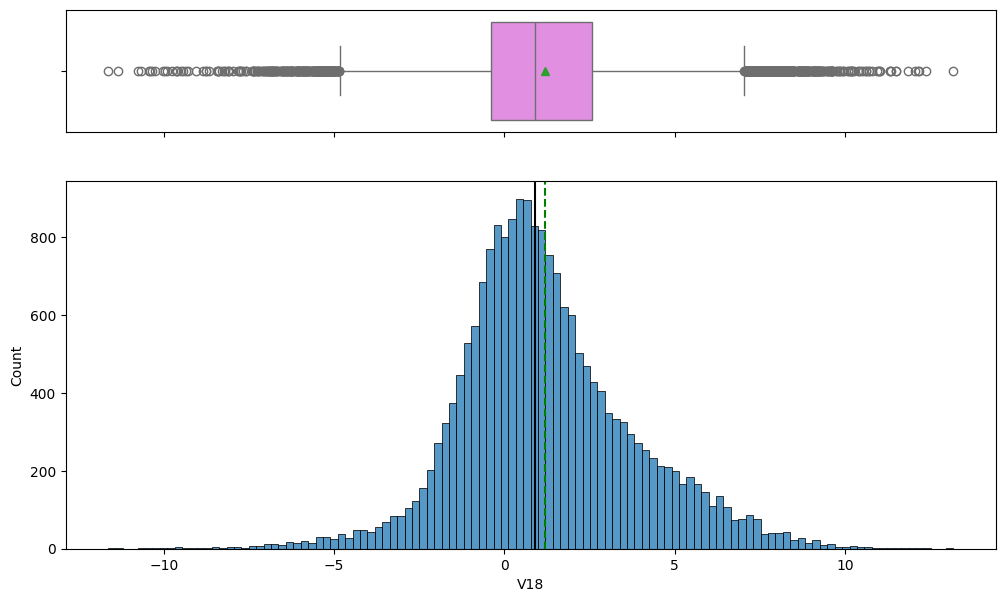

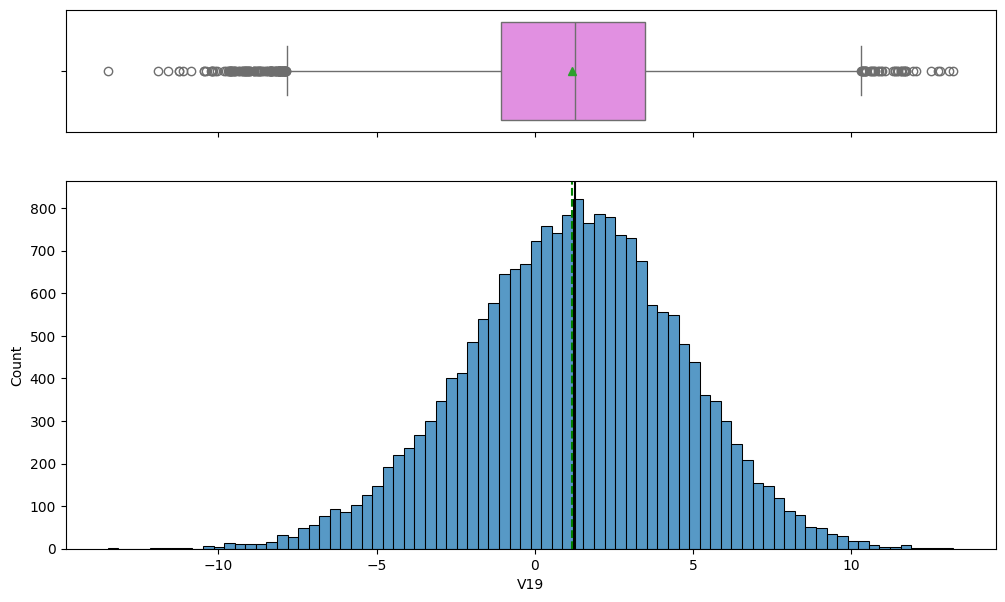

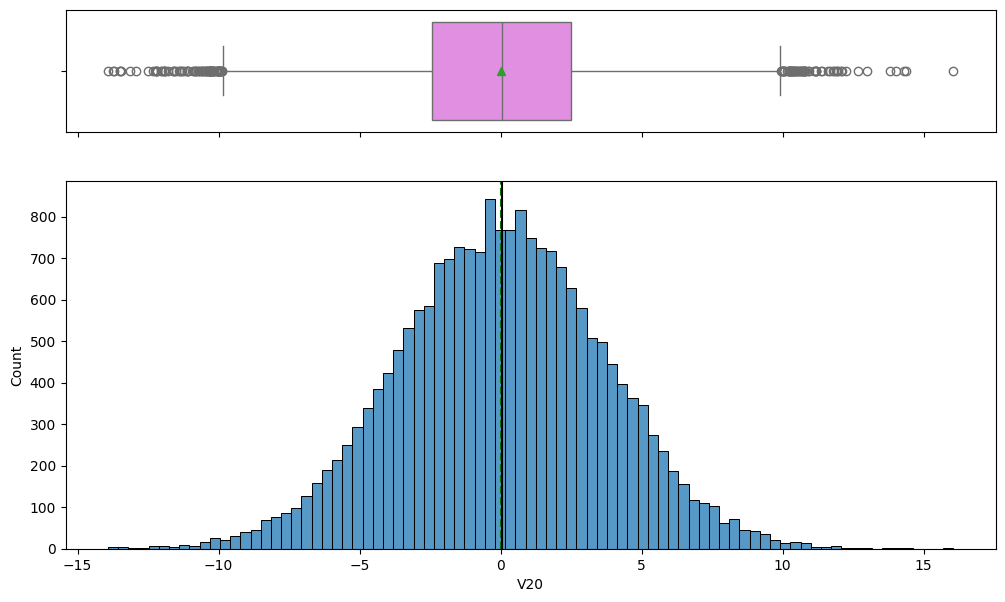

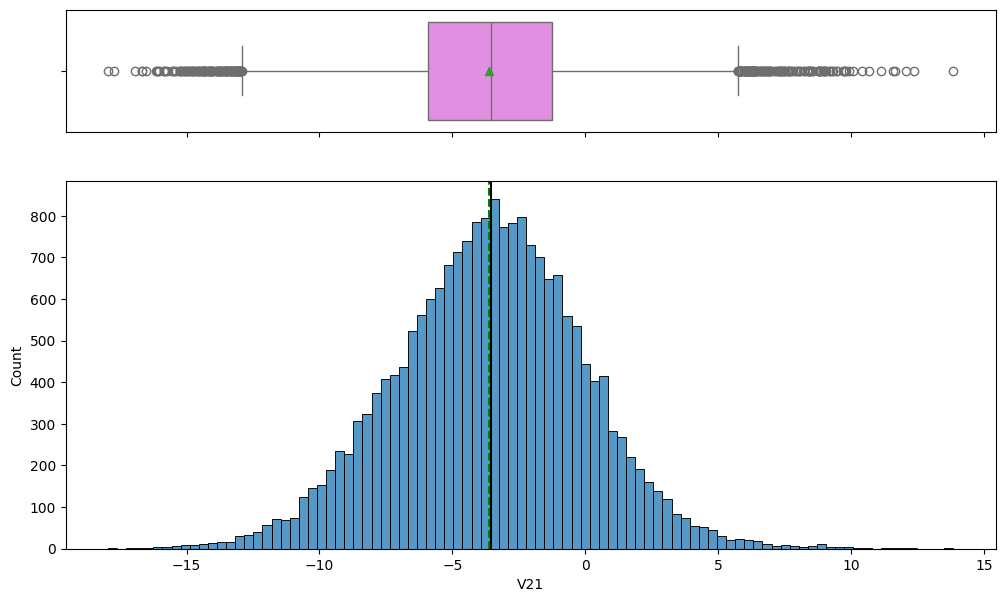

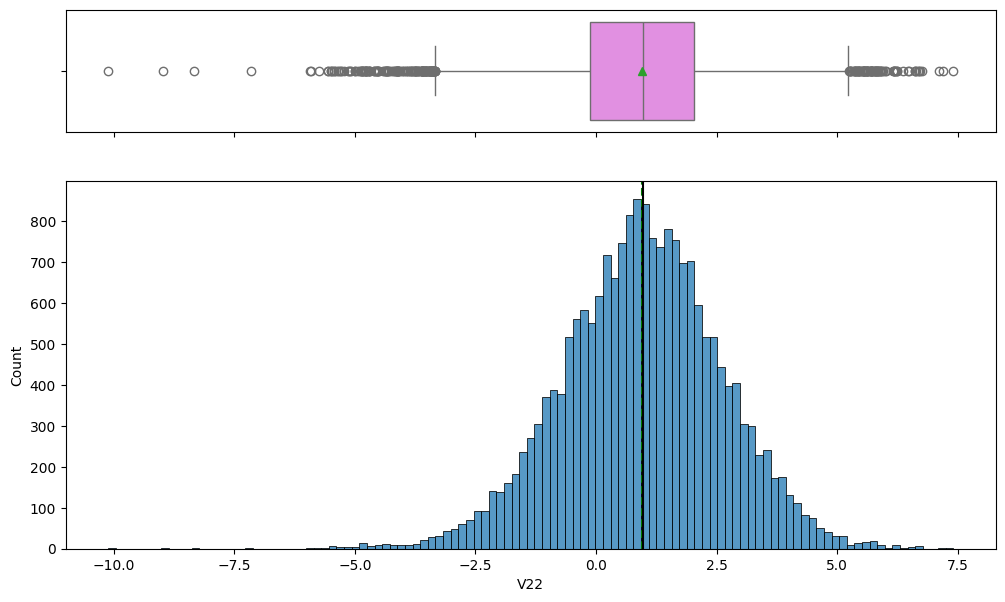

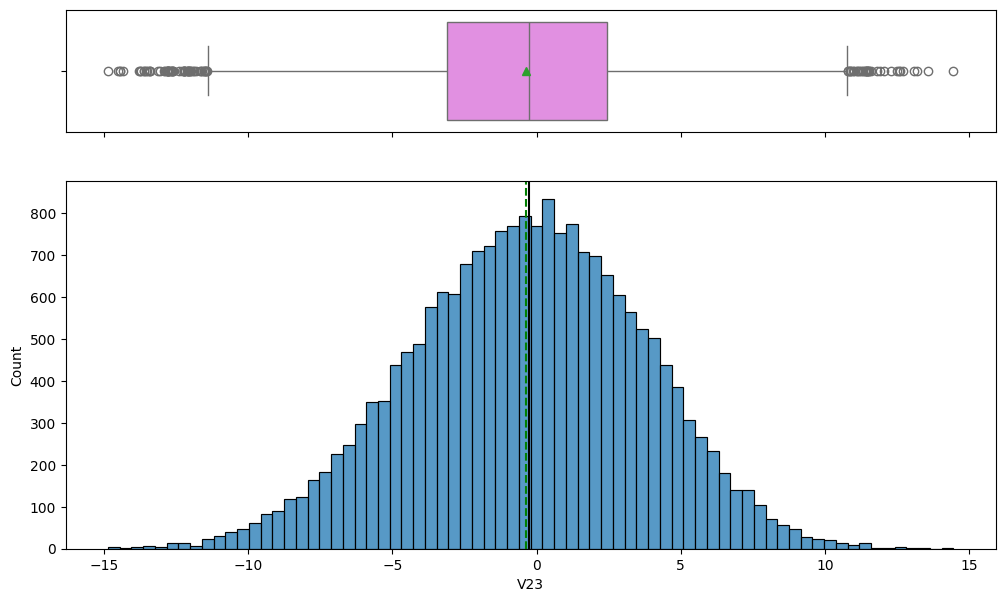

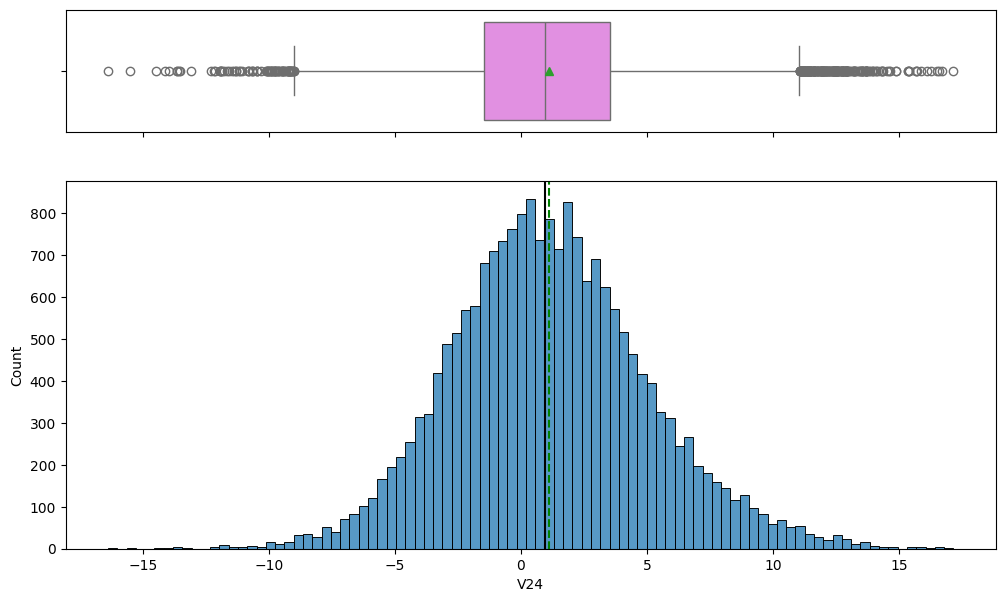

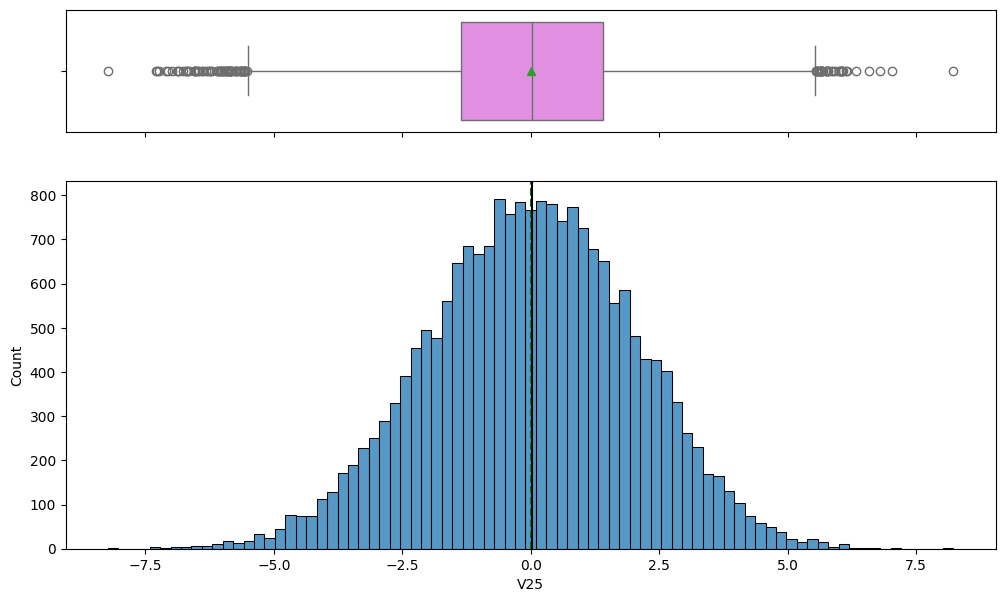

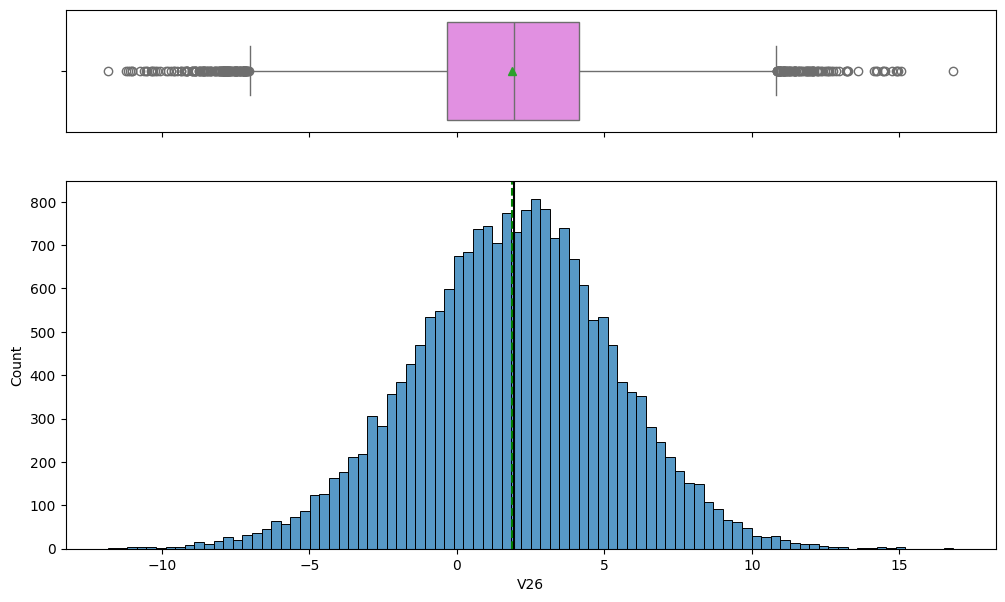

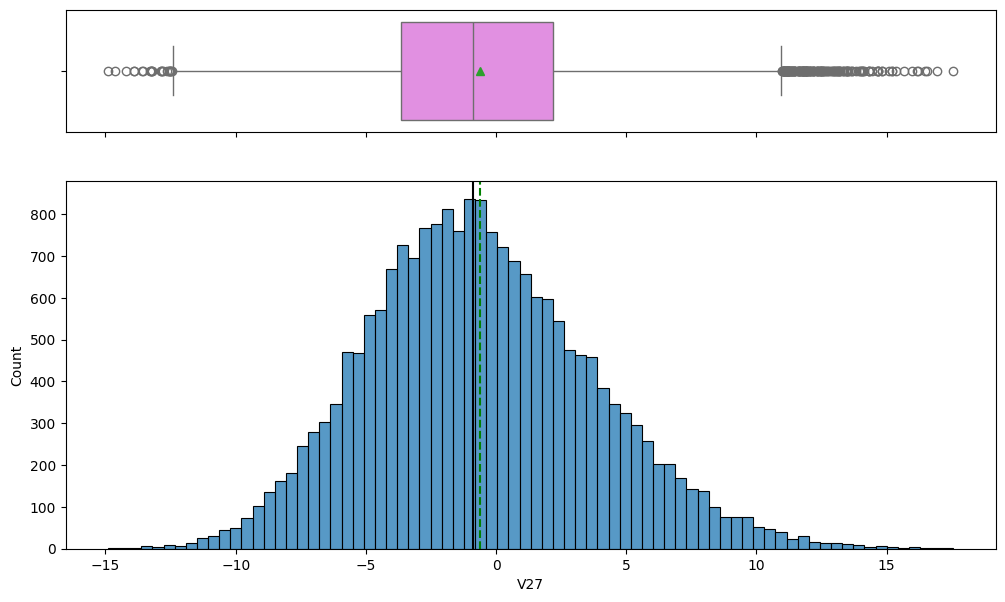

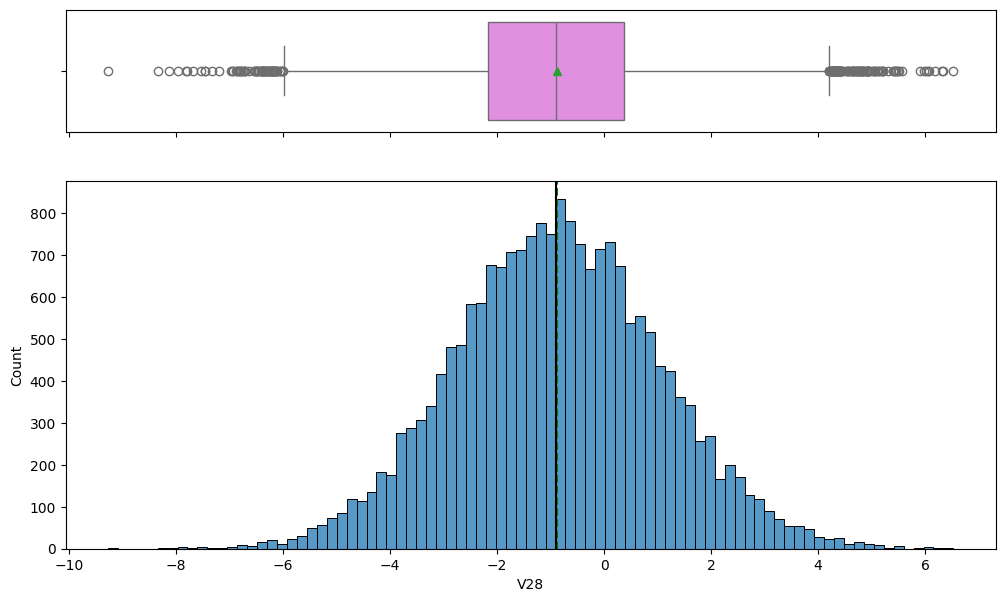

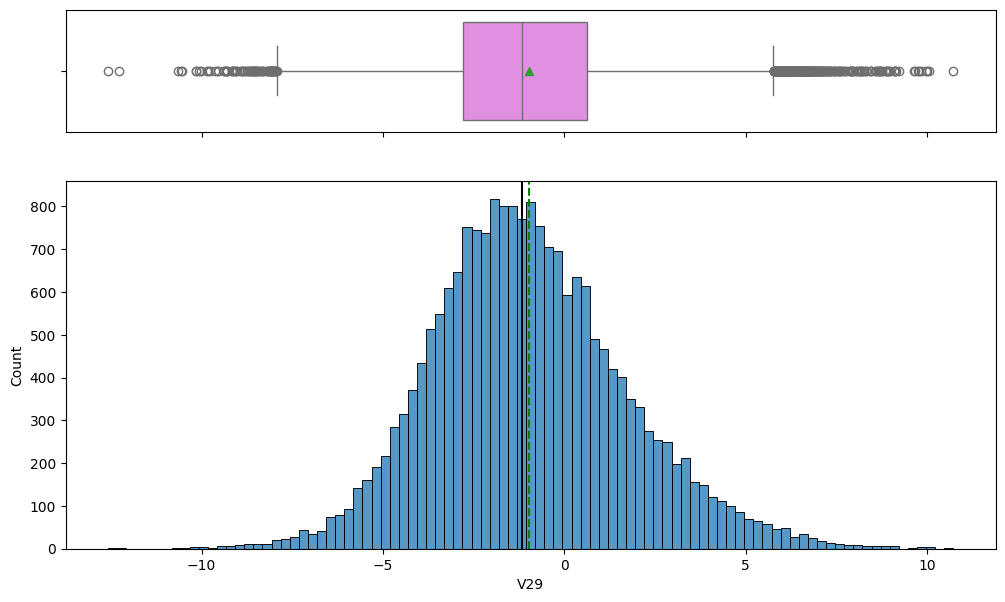

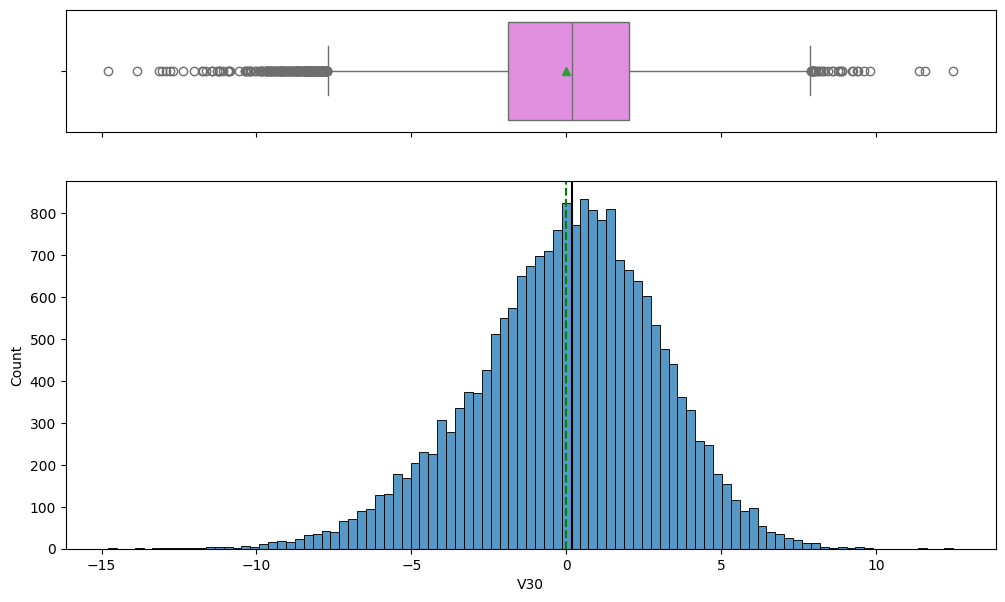

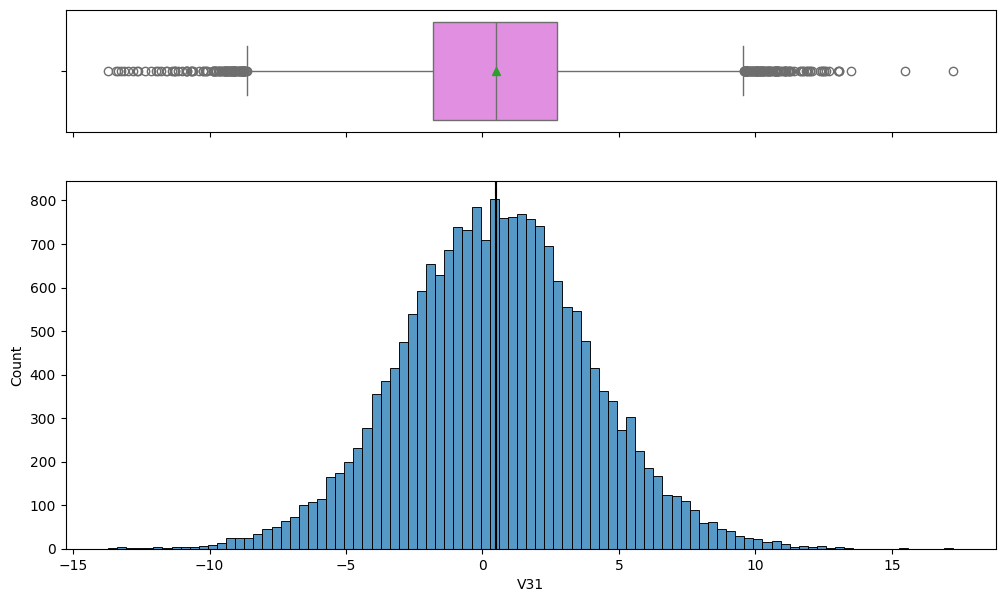

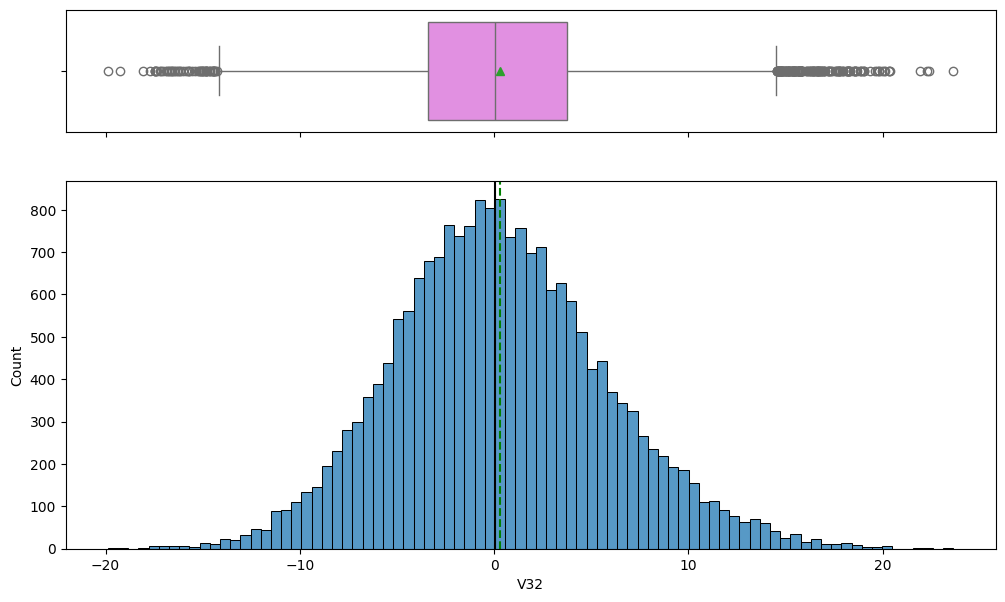

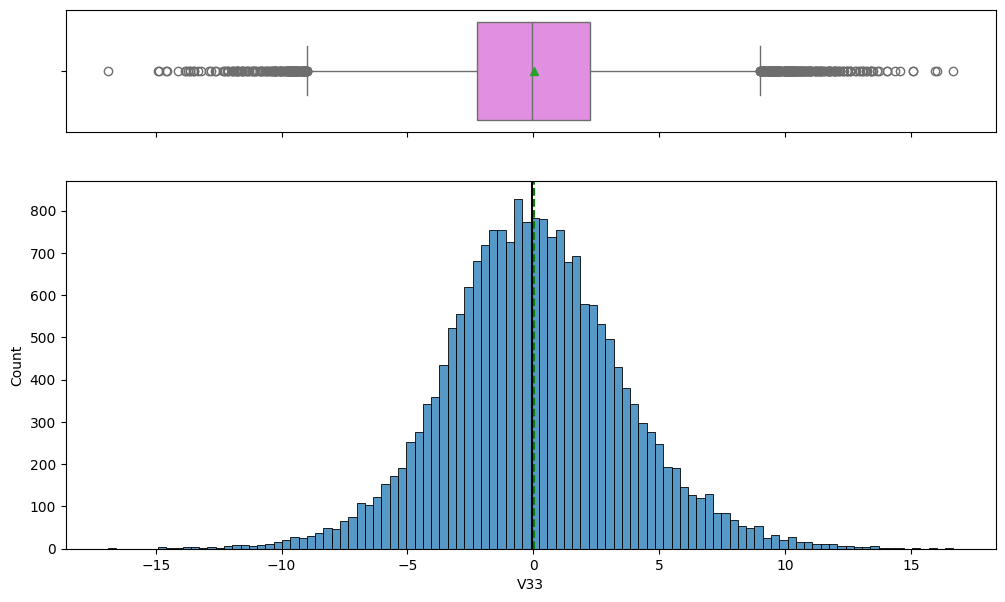

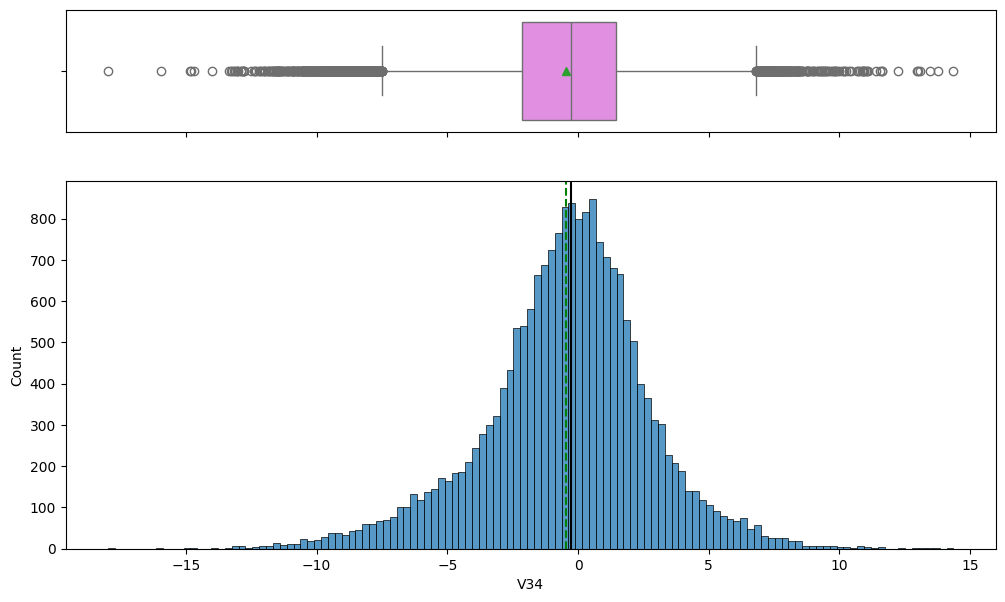

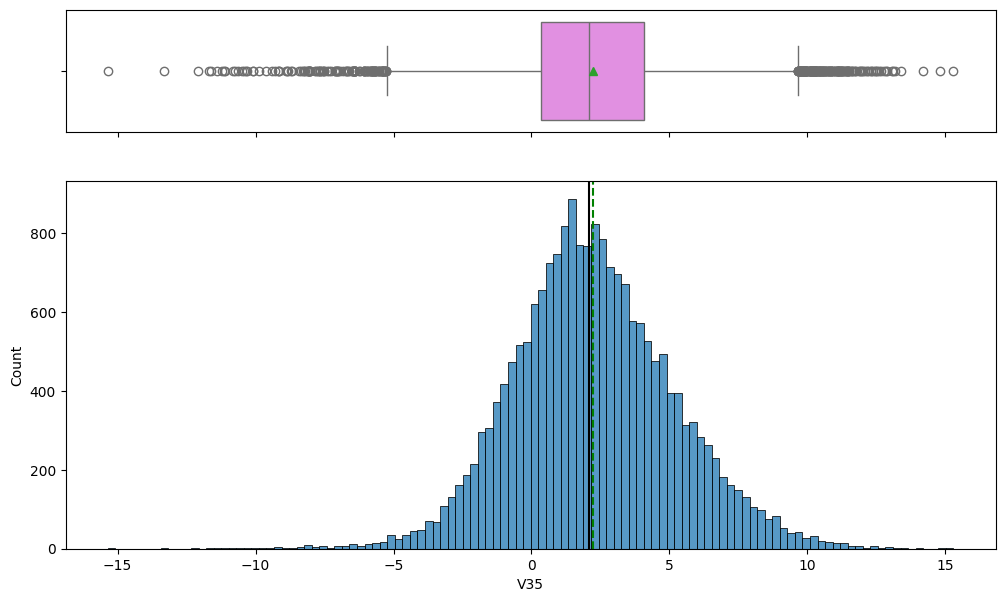

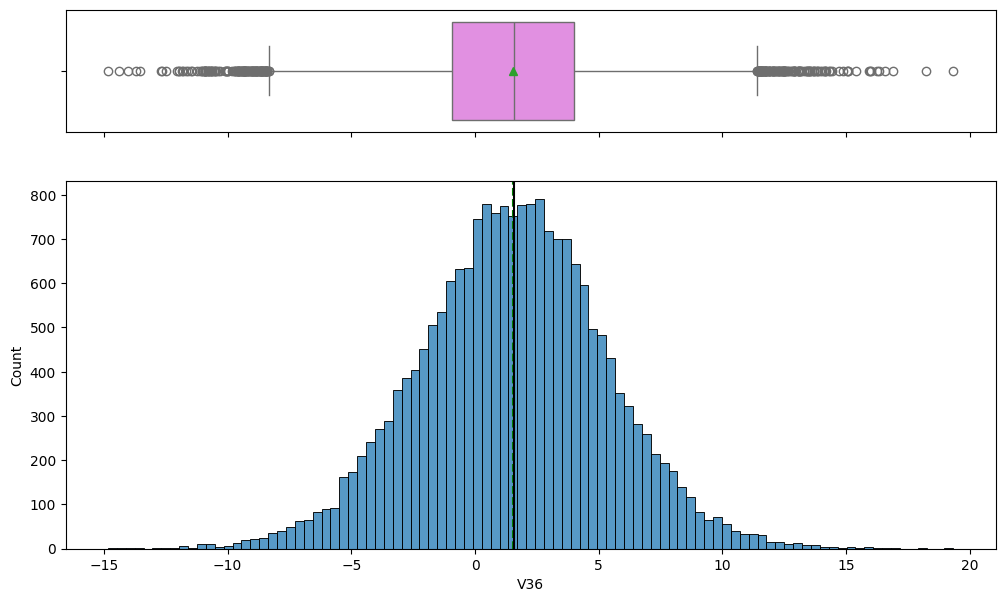

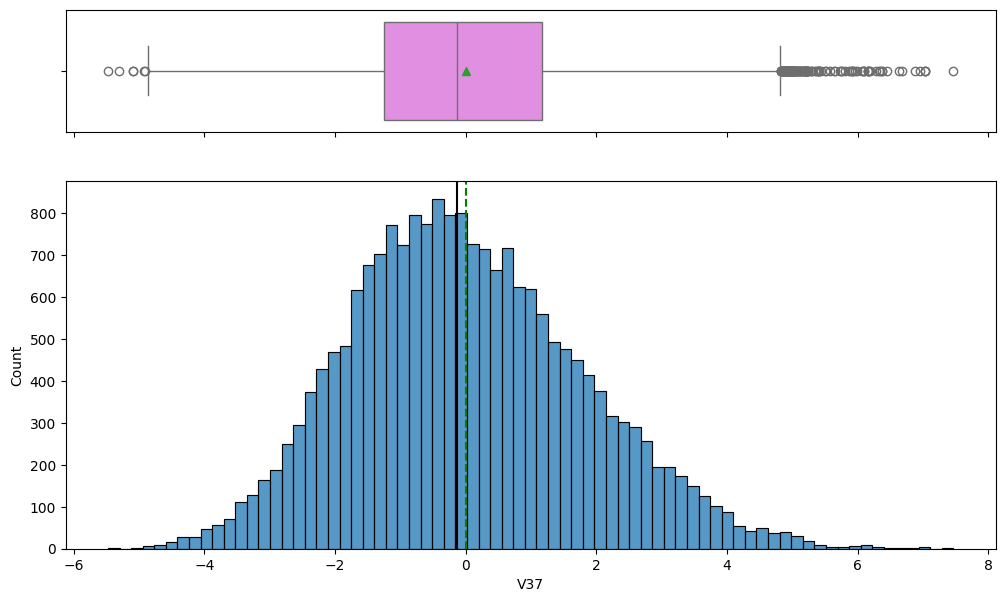

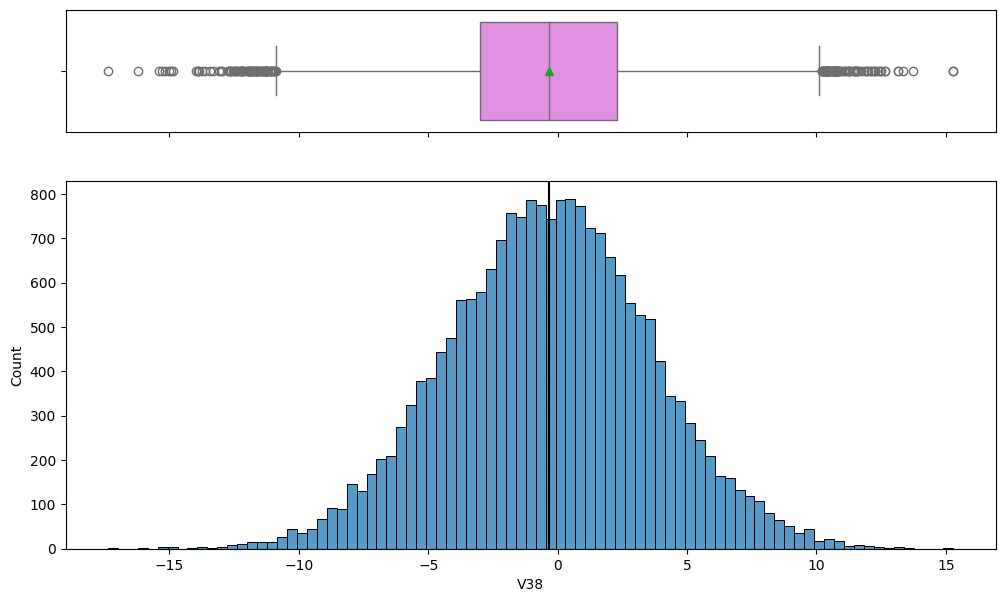

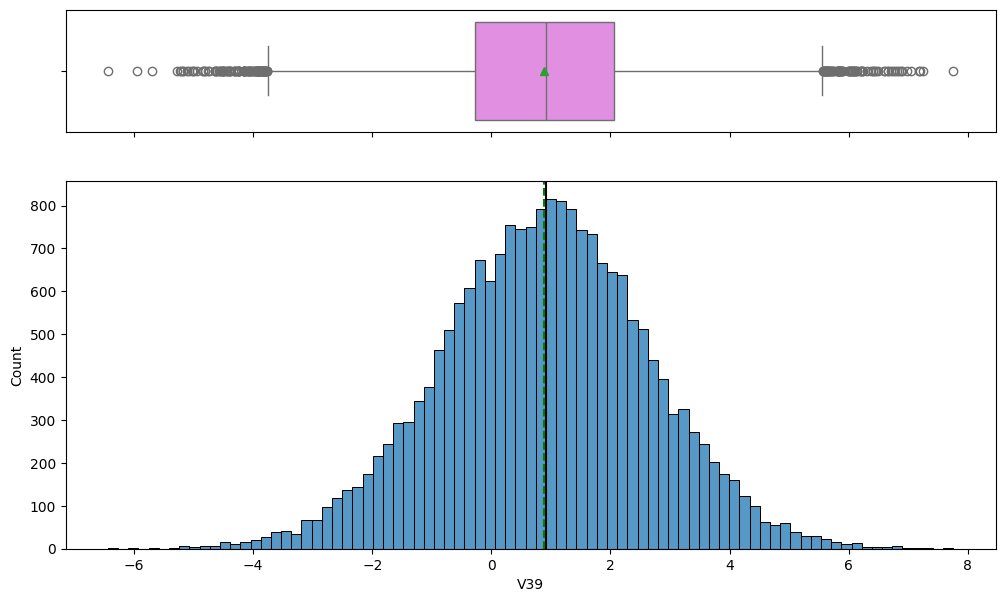

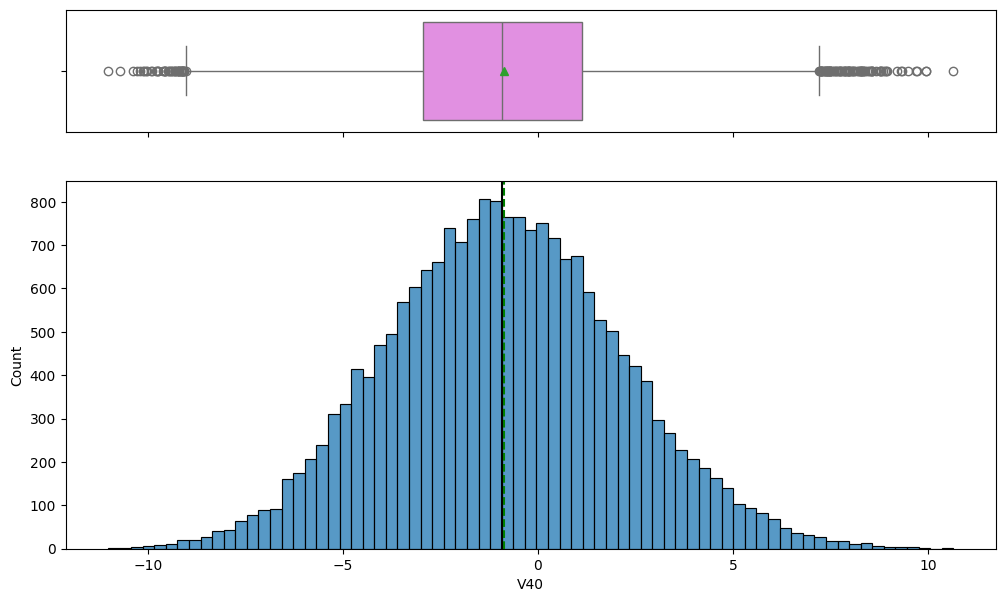

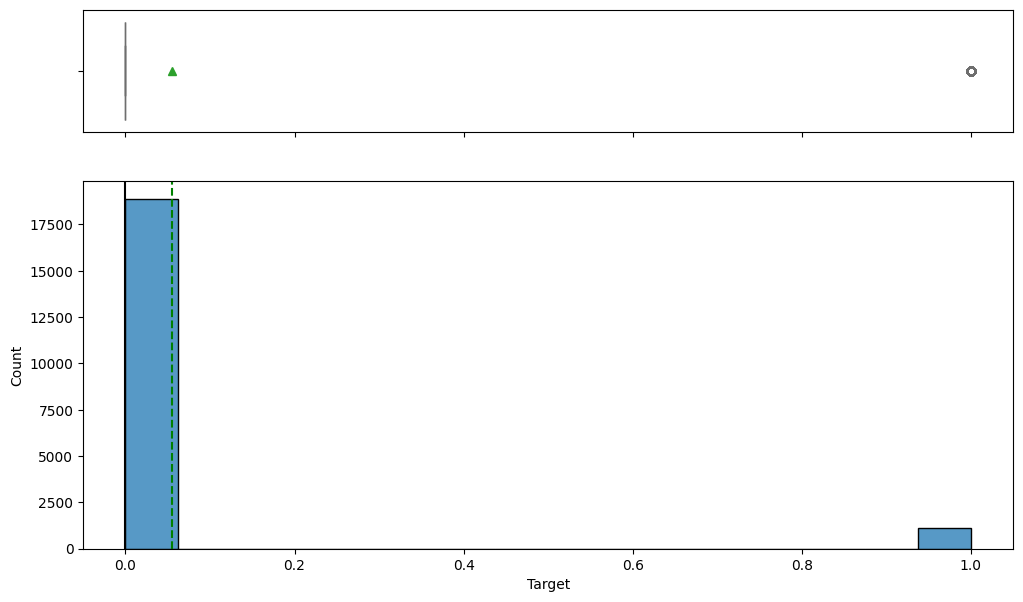

In [ ]:
for feature in data_train.columns:
    histogram_boxplot(data_train, feature, figsize=(12, 7), kde=False, bins=None) ## Please change the dataframe name as you define while reading the data

### Observation
All variables are normally distributed, except for the count variable which is either zero or one. There are no outliers that are seriously skewing the data.

Since the data is encoded, it is difficult to assess what these numbers might mean.

There are very few failures (indicated by 1s) in the dataset, so we will need to deal with class imbalance.

## Look at Train Data

In [ ]:
data_train['Target'].value_counts()

,count
Target,
0,18890
1,1110


In [ ]:
data_test['Target'].value_counts()

,count
Target,
0,4718
1,282


### Observation
Postive samples are only about 6 percent of the population in the train and target sets.

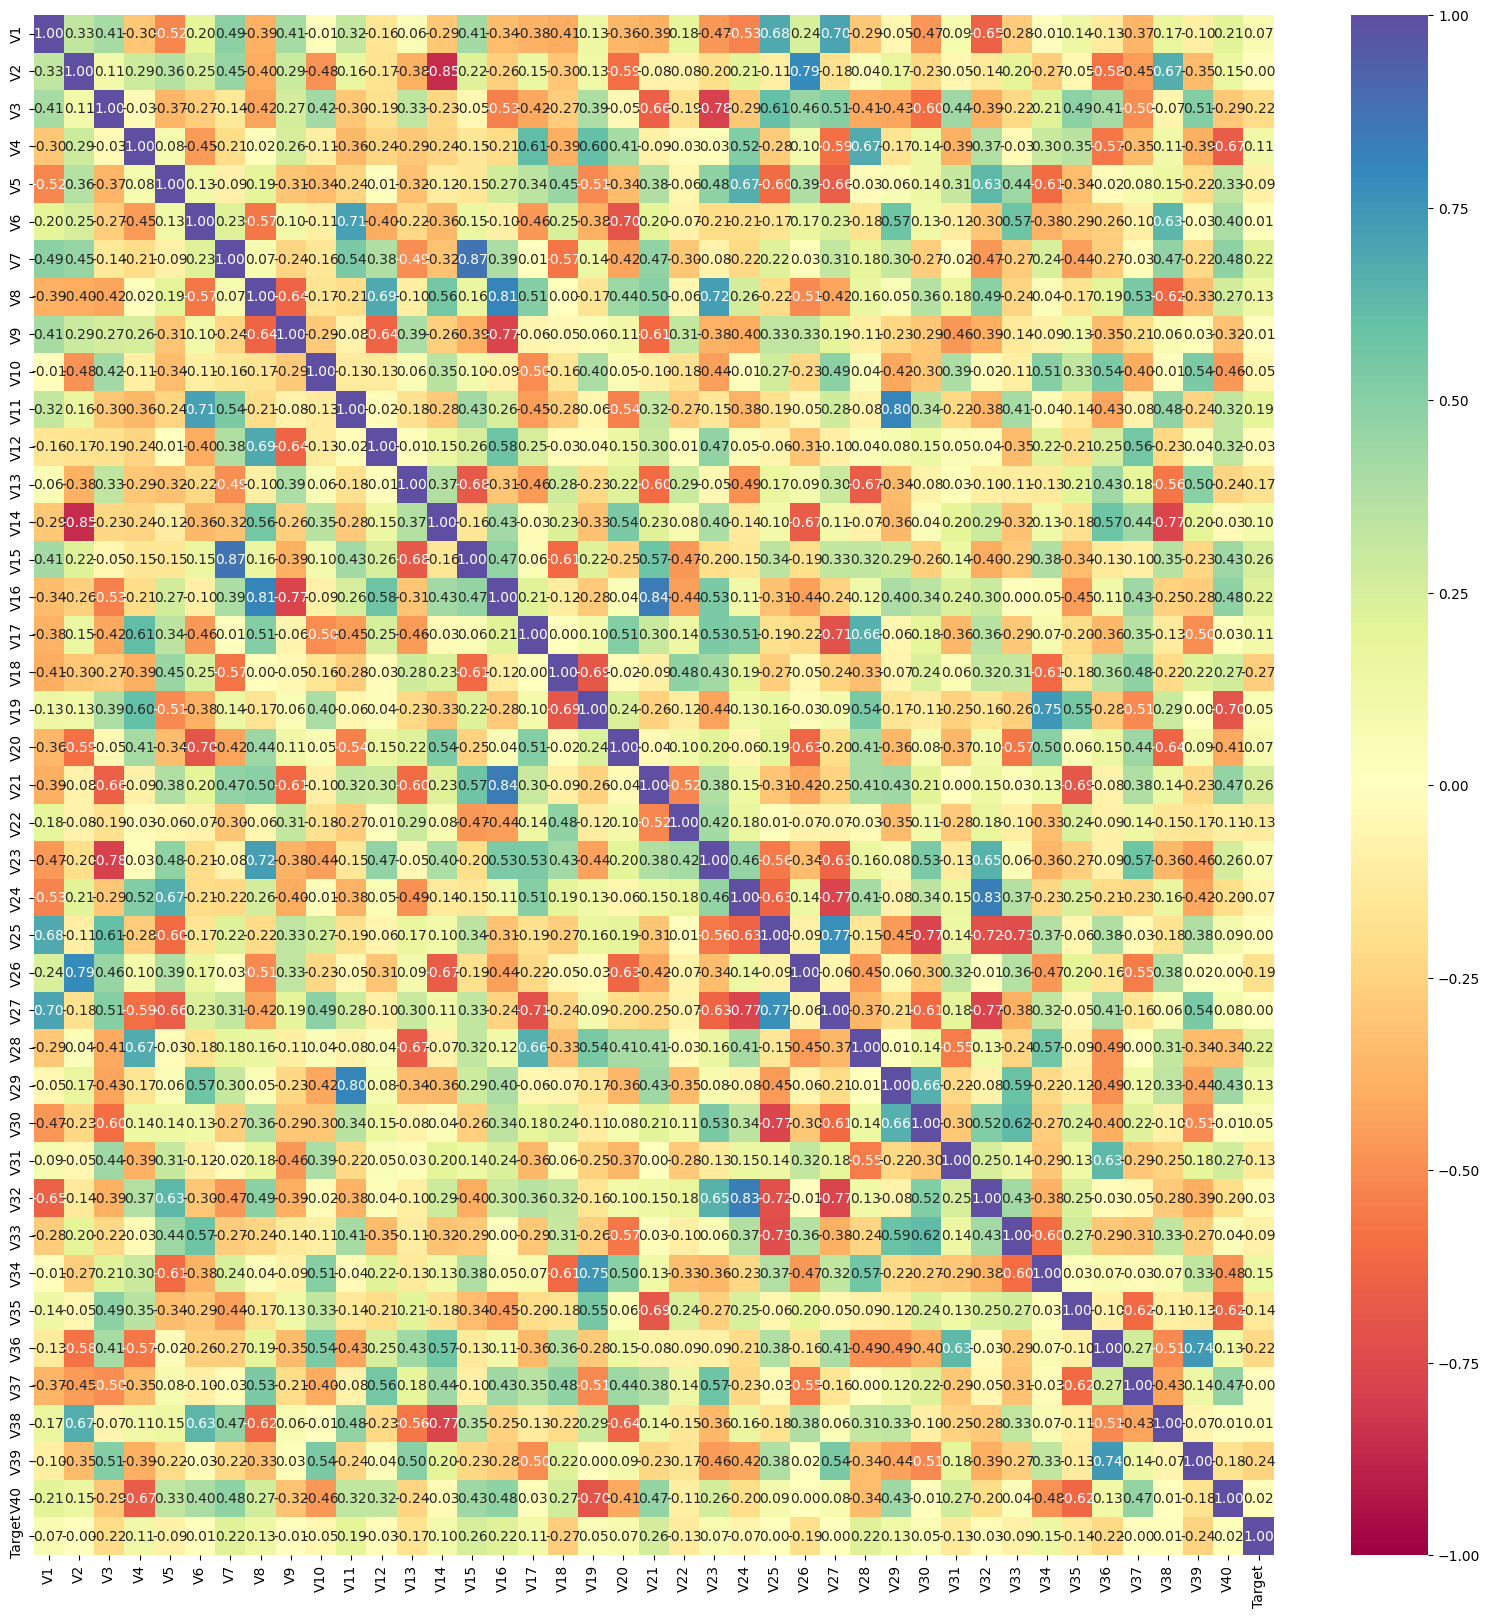

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(data_test.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#Observation
There is some correlation between features such as V32 & V24, V21 & V16, V7 & V14, but nothing serious enough that I would consider removing features.

## Data Pre-processing

In [ ]:
# Dividing trianing data into X and y
X = data_train.drop(columns=['Target'], axis=1)
y = data_train['Target']

In [ ]:
#split train dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
X_train.shape, X_val.shape

((16000, 40), (4000, 40))

In [ ]:
X_test = data_test.drop(columns=['Target'], axis=1)
y_test = data_test['Target']

In [ ]:
X_test.shape

(5000, 40)

#### Observation
There are 5000 rows of test data with 40 columns.

## Missing value imputation




In [ ]:
imputer = SimpleImputer(strategy='median')

In [ ]:
#Fit and transform the training data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns = X_train.columns)

#Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns = X_val.columns)

#Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns = X_test.columns)

In [ ]:
X_val.isna().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:

X_test.isna().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [ ]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

### Model Building with original data

Sample Decision Tree model building with original data

In [ ]:
%%time

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("adaboost", AdaBoostClassifier(random_state=1)))
models.append(("bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

dtree: 0.708314072932717
Logistic Regression: 0.5107601438109913
adaboost: 0.6481317411402158
bagging: 0.714002311248074
Random forest: 0.7241461222393426
Xgboost: 0.8081535695942476
Gradient Boosting: 0.7094119157678481

Validation Performance:

dtree: 0.6812227074235808
Logistic Regression: 0.4017467248908297
adaboost: 0.5458515283842795
bagging: 0.6681222707423581
Random forest: 0.6986899563318777
Xgboost: 0.777292576419214
Gradient Boosting: 0.6637554585152838
CPU times: user 5min 8s, sys: 2.86 s, total: 5min 11s
Wall time: 4min 54s


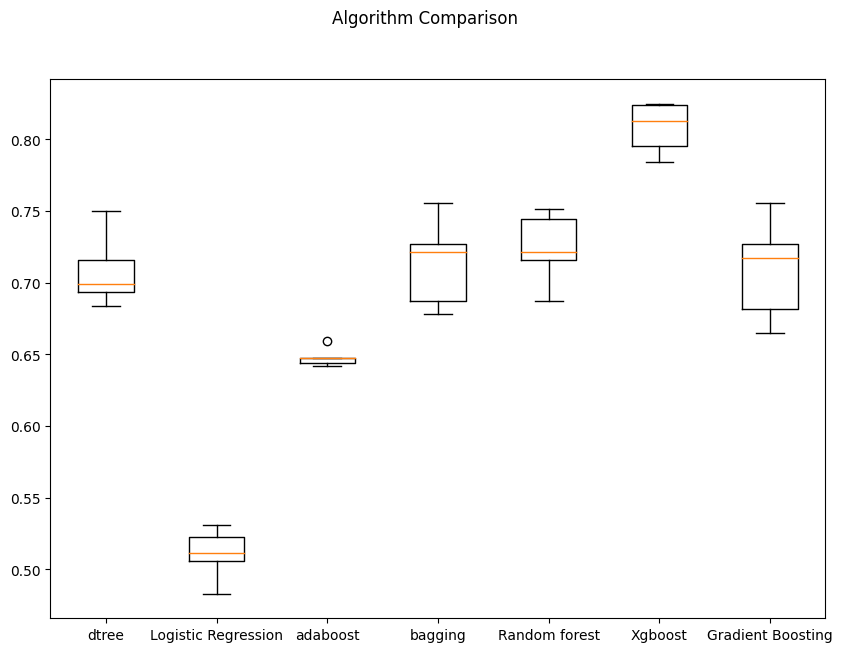

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Observations
XG Boost consistently outperforms the other models on booth the training and validation datasets with a cross-validation score of 0.808 and 0.777 on the validation data.

Random Forest performs with will 0.724 in training and 0.699 in validation.

Bagging and gradient boosting also perform reasonably well.

### Model Building with Oversampled data


In [ ]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [ ]:
print("Before OverSampling, count of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, count of label '0': {} \n".format(sum(y_train == 0)))

print("After OverSampling, count of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, count of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, count of label '1': 881
Before OverSampling, count of label '0': 15119 

After OverSampling, count of label '1': 15119
After OverSampling, count of label '0': 15119 

After OverSampling, the shape of train_X: (30238, 40)
After OverSampling, the shape of train_y: (30238,) 



In [ ]:
%%time

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("adaboost", AdaBoostClassifier(random_state=1)))
models.append(("bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))

results_over = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with Oversampling:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results_over.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance with Oversampling:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset with Oversampling:

dtree: 0.9705010046434129
Logistic Regression: 0.8775716639800331
adaboost: 0.8949011283860772
bagging: 0.9766520608316837
Random forest: 0.9849859192399715
Xgboost: 0.9919306918562624
Gradient Boosting: 0.9218866336919597

Validation Performance with Oversampling:

dtree: 0.7729257641921398
Logistic Regression: 0.8384279475982532
adaboost: 0.8296943231441049
bagging: 0.8122270742358079
Random forest: 0.8471615720524017
Xgboost: 0.8646288209606987
Gradient Boosting: 0.868995633187773
CPU times: user 8min 19s, sys: 4.82 s, total: 8min 24s
Wall time: 7min 58s


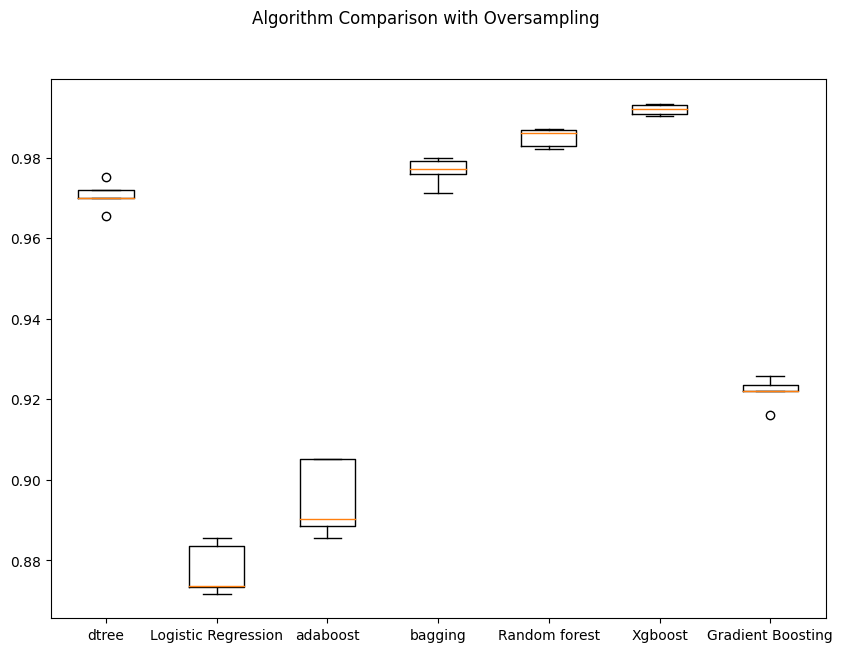

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison with Oversampling")
ax = fig.add_subplot(111)

plt.boxplot(results_over)
ax.set_xticklabels(names)

plt.show()

#### Observation
After oversampling, the clear winners in performance are XG Boost, Random Forest and Bagging, respectively.

### Model Building with Undersampled data

In [ ]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, count of label '1': {}".format(sum(y_train == 1)))
print("Before Under Sampling, count of label '0': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, count of label '1': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, count of label '0': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, count of label '1': 881
Before Under Sampling, count of label '0': 15119 

After Under Sampling, count of label '1': 881
After Under Sampling, count of label '0': 881 

After Under Sampling, the shape of train_X: (1762, 40)
After Under Sampling, the shape of train_y: (1762,) 



In [ ]:
%%time

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Logistic Regression", LogisticRegression(random_state=1)))
models.append(("adaboost", AdaBoostClassifier(random_state=1)))
models.append(("bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1)))
models.append(("Gradient Boosting", GradientBoostingClassifier(random_state=1)))

results_under = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with Undersampling:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold
    )
    results_under.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance with Undersampling:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset with Undersampling:

dtree: 0.8342770929635336
Logistic Regression: 0.8479134565998973
adaboost: 0.8535888546481768
bagging: 0.8467385721623009
Random forest: 0.8955829481253211
Xgboost: 0.8955829481253211
Gradient Boosting: 0.886492039034412

Validation Performance with Undersampling:

dtree: 0.8209606986899564
Logistic Regression: 0.8296943231441049
adaboost: 0.851528384279476
bagging: 0.8471615720524017
Random forest: 0.8646288209606987
Xgboost: 0.8820960698689956
Gradient Boosting: 0.868995633187773
CPU times: user 30.2 s, sys: 2.01 s, total: 32.2 s
Wall time: 21.9 s


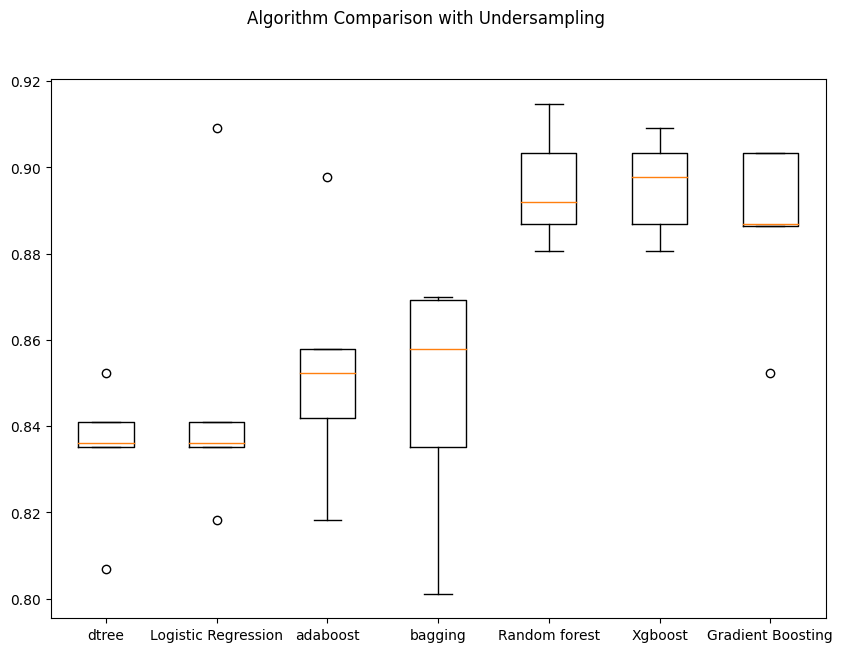

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison with Undersampling")
ax = fig.add_subplot(111)

plt.boxplot(results_under)
ax.set_xticklabels(names)

plt.show()

#### Observation
With Undersampling, random forest and gradient boosting perform nearly as well as XG Boost. Logistic Regression and Decision Tree are underperforming.

## HyperparameterTuning

### Sample Parameter Grids

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

### Decision Tree

#### Decision Tree - Original Data





In [ ]:
# defining model
Model = DecisionTreeClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {'max_depth': np.arange(2,6),
              'min_samples_leaf': [1, 4, 7],
              'max_leaf_nodes' : [10,15],
              'min_impurity_decrease': [0.0001,0.001] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'min_samples_leaf': 7, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': 5} with CV score=0.5481702619414484:


In [ ]:
#building model with best parameters
dtree_tuned_orig = DecisionTreeClassifier(
    min_samples_leaf=7,
    min_impurity_decrease=0.0001,
    max_leaf_nodes=15,
    max_depth=5,
    random_state=1
)
#fit the model on training data
dtree_tuned_orig.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, min_samples_leaf=7,
                       random_state=1)

In [ ]:
dtree_train_perf_orig = model_performance_classification_sklearn(dtree_tuned_orig, X_train, y_train)
dtree_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.974,0.611,0.879,0.721


In [ ]:
dtree_val_perf_orig = model_performance_classification_sklearn(dtree_tuned_orig, X_val, y_val)
dtree_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.969,0.555,0.841,0.668


#### Decision Tree - Oversampled

In [ ]:
# defining model
Model = DecisionTreeClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {'max_depth': np.arange(2,6),
              'min_samples_leaf': [1, 4, 7],
              'max_leaf_nodes' : [10,15],
              'min_impurity_decrease': [0.0001,0.001] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'min_samples_leaf': 7, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': 5} with CV score=0.8935785739664338:


In [ ]:
#building model with best parameters
dtree_tuned_over = DecisionTreeClassifier(
    min_samples_leaf=7,
    min_impurity_decrease=0.0001,
    max_leaf_nodes=15,
    max_depth=5,
    random_state=1
)
#fit the model on training data
dtree_tuned_over.fit(X_train_over, y_train_over)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, min_samples_leaf=7,
                       random_state=1)

In [ ]:
dtree_train_perf_over = model_performance_classification_sklearn(dtree_tuned_over, X_train_over, y_train_over)
dtree_train_perf_over

,Accuracy,Recall,Precision,F1
0,0.894,0.898,0.891,0.895


In [ ]:
dtree_val_perf_over = model_performance_classification_sklearn(dtree_tuned_over, X_val, y_val)
dtree_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.871,0.786,0.278,0.410


#### Decision Tree - Undersampled

In [ ]:
# defining model
Model = DecisionTreeClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {'max_depth': np.arange(2,20),
              'min_samples_leaf': [1, 2, 5, 7],
              'max_leaf_nodes' : [5, 10,15],
              'min_impurity_decrease': [0.0001,0.001] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'min_samples_leaf': 7, 'min_impurity_decrease': 0.001, 'max_leaf_nodes': 15, 'max_depth': 6} with CV score=0.8160760143810991:


In [ ]:
# building model with best parameters
dtree_tuned_un = DecisionTreeClassifier(
    min_samples_leaf=7,
    min_impurity_decrease=0.001,
    max_leaf_nodes=15,
    max_depth=6,
    random_state=1
)
#fit the model on training data
dtree_tuned_un.fit(X_train_un, y_train_un)

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=15,
                       min_impurity_decrease=0.001, min_samples_leaf=7,
                       random_state=1)

In [ ]:
dtree_train_perf_un = model_performance_classification_sklearn(dtree_tuned_un, X_train_un, y_train_un)
dtree_train_perf_un

,Accuracy,Recall,Precision,F1
0,0.900,0.875,0.921,0.898


In [ ]:
dtree_val_perf_un = model_performance_classification_sklearn(dtree_tuned_un, X_val, y_val)
dtree_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.888,0.812,0.315,0.454


### Gradient Boost

#### Gradient Boost - Original Data

In [ ]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": np.arange(100,150,25),
               "learning_rate": [0.2, 0.05, 1],
               "subsample":[0.5,0.7],
               "max_features":[0.5,0.7] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 0.2} with CV score=0.7389252696456087:


In [ ]:
# building model with best parameters
gb_tuned_orig = GradientBoostingClassifier(
                n_estimators= 125,
                learning_rate= 0.05,
                subsample=0.7,
                max_features=0.5,
                random_state=1
)

# Fit the model on training data
gb_tuned_orig.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_features=0.5,
                           n_estimators=125, random_state=1, subsample=0.7)

In [ ]:
gb_train_perf_orig = model_performance_classification_sklearn(gb_tuned_orig, X_train, y_train)
gb_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.984,0.728,0.974,0.833


In [ ]:
gb_val_perf_orig = model_performance_classification_sklearn(gb_tuned_orig, X_val, y_val)
gb_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.976,0.620,0.928,0.743


#### Gradient Boost - Oversampled

In [ ]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": np.arange(100,150,25),
               "learning_rate": [0.2, 0.05, 1],
               "subsample":[0.5,0.7],
               "max_features":[0.5,0.7] }



#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 1} with CV score=0.964812298830658:


In [ ]:
# building model with best parameters
gb_tuned_over = GradientBoostingClassifier(
                n_estimators= 125,
                learning_rate= 1,
                subsample=0.7,
                max_features=0.5,
                random_state=1
)

# Fit the model on training data
gb_tuned_over.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=1, max_features=0.5, n_estimators=125,
                           random_state=1, subsample=0.7)

In [ ]:
gb_train_perf_over = model_performance_classification_sklearn(gb_tuned_over, X_train_over, y_train_over)
gb_train_perf_over

,Accuracy,Recall,Precision,F1
0,0.993,0.993,0.993,0.993


In [ ]:
gb_val_perf_over = model_performance_classification_sklearn(gb_tuned_over, X_val, y_val)
gb_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.971,0.860,0.701,0.773


#### Gradient Boost - Undersampled

In [ ]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": np.arange(100,150,25),
               "learning_rate": [0.2, 0.05, 1],
               "subsample":[0.5,0.7],
               "max_features":[0.5,0.7] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 0.2} with CV score=0.8955444273240882:


In [ ]:
# building model with best parameters
gb_tuned_un = GradientBoostingClassifier(
                n_estimators= 125,
                learning_rate= 0.2,
                subsample=0.7,
                max_features=0.5,
                random_state=1
)

# Fit the model on training data
gb_tuned_un.fit(X_train_un, y_train_un)

GradientBoostingClassifier(learning_rate=0.2, max_features=0.5,
                           n_estimators=125, random_state=1, subsample=0.7)

In [ ]:
gb_train_perf_un = model_performance_classification_sklearn(gb_tuned_un, X_train_un, y_train_un)
gb_train_perf_un

,Accuracy,Recall,Precision,F1
0,0.995,0.991,1.000,0.995


In [ ]:
gb_val_perf_un = model_performance_classification_sklearn(gb_tuned_un, X_val, y_val)
gb_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.933,0.904,0.459,0.609


### AdaBoost

#### Adaboost - Original Data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": [100, 150, 200],
              "learning_rate": [0.2, 0.05],
               "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                                  DecisionTreeClassifier(max_depth=2, random_state=1),
                                  DecisionTreeClassifier(max_depth=3, random_state=1), ] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 150, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.7695749871597328:


In [ ]:
# building model with best parameters
adb_tuned_orig = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.2,
    random_state=1,
    base_estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)

# Fit the model on training data
adb_tuned_orig.fit(X_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=0.2, n_estimators=150, random_state=1)

In [ ]:
adb_train_perf_orig = model_performance_classification_sklearn(adb_tuned_orig, X_train, y_train)
adb_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.997,0.938,0.999,0.967


In [ ]:
adb_val_perf_orig = model_performance_classification_sklearn(adb_tuned_orig, X_val, y_val)
adb_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.984,0.738,0.971,0.839


#### Adaboost - Oversampled

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {"n_estimators": [100, 150, 200],
              "learning_rate": [0.2, 0.05],
              "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                                  DecisionTreeClassifier(max_depth=2, random_state=1),
                                  DecisionTreeClassifier(max_depth=3, random_state=1), ] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 200, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.9700379979242036:


In [ ]:
# building model with best parameters
adb_tuned_over = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.2,
    random_state=1,
    base_estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)

# Fit the model on training data
adb_tuned_over.fit(X_train_over, y_train_over)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=0.2, n_estimators=200, random_state=1)

In [ ]:
adb_train_perf_over = model_performance_classification_sklearn(adb_tuned_over, X_train_over, y_train_over)
adb_train_perf_over

,Accuracy,Recall,Precision,F1
0,0.989,0.983,0.995,0.989


In [ ]:
adb_val_perf_over = model_performance_classification_sklearn(adb_tuned_over, X_val, y_val)
adb_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.983,0.865,0.843,0.853


#### Adaboost - Undersampled

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": [100, 150, 200],
              "learning_rate": [0.2, 0.05],
               "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                                  DecisionTreeClassifier(max_depth=2, random_state=1),
                                  DecisionTreeClassifier(max_depth=3, random_state=1), ] }
#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 150, 'learning_rate': 0.2, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8774011299435027:


In [ ]:
# building model with best parameters
adb_tuned_un = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.2,
    random_state=1,
    base_estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)

# Fit the model on training data
adb_tuned_un.fit(X_train_un, y_train_un)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=0.2, n_estimators=150, random_state=1)

In [ ]:
adb_train_perf_un = model_performance_classification_sklearn(adb_tuned_un, X_train_un, y_train_un)
adb_train_perf_un

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [ ]:
adb_val_perf_un = model_performance_classification_sklearn(adb_tuned_un, X_val, y_val)
adb_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.938,0.860,0.477,0.614


### Bagging Classifier


#### Bagging Classifier - Original Data


In [ ]:
# defining model
Model = BaggingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { 'max_samples': [0.8,0.9,1],
   'max_features': [0.7,0.8,0.9],
   'n_estimators' : [30,50,70], }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.8} with CV score=0.7309899845916795:


In [ ]:
# building model with best parameters
bg_tuned_orig = BaggingClassifier(
    max_samples = 0.9 ,
    max_features = 0.8,
    n_estimators = 70,
    random_state = 1
)

# Fit the model on training data
bg_tuned_orig.fit(X_train, y_train)

BaggingClassifier(max_features=0.8, max_samples=0.9, n_estimators=70,
                  random_state=1)

In [ ]:
bg_train_perf_orig = model_performance_classification_sklearn(bg_tuned_orig, X_train, y_train)
bg_train_perf_orig

,Accuracy,Recall,Precision,F1
0,1.000,0.995,1.000,0.998


In [ ]:
bg_val_perf_orig = model_performance_classification_sklearn(bg_tuned_orig, X_val, y_val)
bg_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.981,0.677,0.981,0.801


#### Bagging - Oversampled

In [ ]:
# defining model
Model = BaggingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { 'max_samples': [0.8,0.9,1],
   'max_features': [0.7,0.8,0.9],
   'n_estimators' : [30,50,70], }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.9} with CV score=0.9831336517037806:


In [ ]:
# building model with best parameters
bg_tuned_over = BaggingClassifier(
    max_samples = 0.9,
    max_features =0.9,
    n_estimators =70,
    random_state = 1
)

# Fit the model on training data
bg_tuned_over.fit(X_train_over, y_train_over)

BaggingClassifier(max_features=0.9, max_samples=0.9, n_estimators=70,
                  random_state=1)

In [ ]:
bg_train_perf_over = model_performance_classification_sklearn(bg_tuned_over, X_train_over, y_train_over)
bg_train_perf_over

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [ ]:
bg_val_perf_over = model_performance_classification_sklearn(bg_tuned_over, X_val, y_val)
bg_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.985,0.838,0.893,0.865


#### Bagging - Undersampled

In [ ]:
# defining model
Model = BaggingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { 'max_samples': [0.8,0.9,1],
   'max_features': [0.7,0.8,0.9],
   'n_estimators' : [30,50,70], }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.8} with CV score=0.895550847457627:


In [ ]:
# building model with best parameters
bg_tuned_un = BaggingClassifier(
    max_samples = 0.9,
    max_features =0.8,
    n_estimators =70,
    random_state = 1
)

# Fit the model on training data
bg_tuned_un.fit(X_train_un, y_train_un)

BaggingClassifier(max_features=0.8, max_samples=0.9, n_estimators=70,
                  random_state=1)

In [ ]:
bg_train_perf_un = model_performance_classification_sklearn(bg_tuned_un, X_train_un, y_train_un)
bg_train_perf_un

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [ ]:
bg_val_perf_un = model_performance_classification_sklearn(bg_tuned_un, X_val, y_val)
bg_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.950,0.869,0.541,0.667


##### Observation
Bagging shows definite signs of overfitting.

### Logistic Regression

#### Logistic Regression - Original Data




In [ ]:
# defining model
Model = LogisticRegression(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = param_grid = {'C': np.arange(0.1,1.1,0.1)}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'C': 0.30000000000000004} with CV score=0.5085066769388803:


In [ ]:
#building model with best parameters
lr_tuned_orig = LogisticRegression(C=0.3, random_state=1)

# Fit the model on training data
lr_tuned_orig.fit(X_train, y_train)

LogisticRegression(C=0.3, random_state=1)

In [ ]:
lr_train_perf_orig = model_performance_classification_sklearn(lr_tuned_orig, X_train, y_train)
lr_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.968,0.513,0.851,0.640


In [ ]:
lr_val_perf_orig = model_performance_classification_sklearn(lr_tuned_orig, X_val, y_val)
lr_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.961,0.402,0.821,0.540


#### Logistic Regression - Oversampled

In [ ]:
# defining model
Model = LogisticRegression(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = param_grid = {'C': np.arange(0.1,1.1,0.1)}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'C': 0.2} with CV score=0.8774398264102201:


In [ ]:
#building model with best parameters
lr_tuned_over = LogisticRegression(C=0.2, random_state=1)

# Fit the model on training data
lr_tuned_over.fit(X_train_over, y_train_over)

LogisticRegression(C=0.2, random_state=1)

In [ ]:
lr_train_perf_over = model_performance_classification_sklearn(lr_tuned_over, X_train_over, y_train_over)
lr_train_perf_over

,Accuracy,Recall,Precision,F1
0,0.878,0.877,0.879,0.878


In [ ]:
lr_val_perf_over = model_performance_classification_sklearn(lr_tuned_over, X_val, y_val)
lr_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.881,0.838,0.304,0.447


#### Logistic Regression - Undersampled

In [ ]:
# defining model
Model = LogisticRegression(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = param_grid = {'C': np.arange(0.1,1.1,0.1)}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'C': 0.1} with CV score=0.8501412429378531:


In [ ]:
#building model with best parameters
lr_tuned_un = LogisticRegression(C=0.1, random_state=1)

# Fit the model on training data
lr_tuned_un.fit(X_train_un, y_train_un)

LogisticRegression(C=0.1, random_state=1)

In [ ]:
lr_train_perf_un = model_performance_classification_sklearn(lr_tuned_un, X_train_un, y_train_un)
lr_train_perf_un

,Accuracy,Recall,Precision,F1
0,0.868,0.851,0.881,0.866


In [ ]:
lr_val_perf_un = model_performance_classification_sklearn(lr_tuned_un, X_val, y_val)
lr_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.878,0.830,0.297,0.438


### Random Forest

#### Random Forest - Original Data




In [ ]:
# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": [200,250,300],
               "min_samples_leaf": np.arange(1, 4),
               "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
               "max_samples": np.arange(0.4, 0.7, 0.1) }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 250, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.7094054956343092:


In [ ]:
#building model with best parameters
rf_tuned_orig = RandomForestClassifier(
    n_estimators = 250,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    max_samples = 0.6,
    random_state = 1
)
# fit the model on the training data
rf_tuned_orig.fit(X_train, y_train)

RandomForestClassifier(max_samples=0.6, n_estimators=250, random_state=1)

In [ ]:
rf_train_perf_orig = model_performance_classification_sklearn(rf_tuned_orig, X_train, y_train)
rf_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.995,0.910,0.999,0.952


In [ ]:
rf_val_perf_orig = model_performance_classification_sklearn(rf_tuned_orig, X_val, y_val)
rf_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.981,0.664,1.000,0.798


#### Random Forest - Oversampled

In [ ]:
# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": [200,250,300],
               "min_samples_leaf": np.arange(1, 4),
               "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
               "max_samples": np.arange(0.4, 0.7, 0.1) }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 300, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.9809510463868717:


In [ ]:
#building the model with the best parameters
rf_tuned_over = RandomForestClassifier(
    n_estimators = 300,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    max_samples = 0.6,
    random_state = 1
)

#fit the model
rf_tuned_over.fit(X_train_over, y_train_over)

RandomForestClassifier(max_samples=0.6, n_estimators=300, random_state=1)

In [ ]:
rf_train_perf_over = model_performance_classification_sklearn(rf_tuned_over, X_train_over, y_train_over)
rf_train_perf_over

,Accuracy,Recall,Precision,F1
0,1.000,0.999,1.000,1.000


In [ ]:
rf_val_perf_over = model_performance_classification_sklearn(rf_tuned_over, X_val, y_val)
rf_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.988,0.852,0.938,0.892


####Random Forest - Undersampled


In [ ]:
# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = { "n_estimators": [200,250,300],
               "min_samples_leaf": np.arange(1, 4),
               "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
               "max_samples": np.arange(0.4, 0.7, 0.1) }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 250, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.898959938366718:


In [ ]:
#build model from best parameters
rf_tuned_un = RandomForestClassifier(
    n_estimators = 250,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    max_samples = 0.6,
    random_state = 1
)

#fit the model
rf_tuned_un.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.6, n_estimators=250, random_state=1)

In [ ]:
rf_train_perf_un = model_performance_classification_sklearn(rf_tuned_un, X_train_un, y_train_un)
rf_train_perf_un

,Accuracy,Recall,Precision,F1
0,0.989,0.978,1.000,0.989


In [ ]:
rf_val_perf_un = model_performance_classification_sklearn(rf_tuned_un, X_val, y_val)
rf_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.946,0.878,0.517,0.650


### XG Boost

#### XGBoost - Original Data


In [ ]:
# defining model
Model = XGBClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators': [150, 200, 250],
            'scale_pos_weight': [5,10],
            'learning_rate': [0.1,0.2],
            'gamma': [0,3,5],
            'subsample': [0.8,0.9] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.1, 'gamma': 5} with CV score=0.8558551617873651:


In [ ]:
#building model with the best parameters
xgb_tuned_orig = XGBClassifier(
    n_estimators = 200,
    scale_pos_weight = 10,
    learning_rate = 0.1,
    gamma = 5,
    subsample = 0.8,
    random_state = 1
)

# Fit the model on training data
xgb_tuned_orig.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=5, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb_train_perf_orig = model_performance_classification_sklearn(xgb_tuned_orig, X_train, y_train)
xgb_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.998,1.000,0.968,0.984


In [ ]:
xgb_val_perf_orig = model_performance_classification_sklearn(xgb_tuned_orig, X_val, y_val)
xgb_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.989,0.860,0.938,0.897


####XGB - Oversampled

In [ ]:
# defining model
Model = XGBClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators': [150, 200, 250],
            'scale_pos_weight': [5,10],
            'learning_rate': [0.1,0.2],
            'gamma': [0,3,5],
            'subsample': [0.8,0.9] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.9968251780441658:


In [ ]:
#building the model with the best parameters
xgb_tuned_over = XGBClassifier(
    n_estimators = 200,
    scale_pos_weight = 10,
    learning_rate = 0.2,
    gamma = 0,
    subsample = 0.9,
    random_state = 1
)

# Fit the model on training data
xgb_tuned_over.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb_train_perf_over = model_performance_classification_sklearn(xgb_tuned_over, X_train_over, y_train_over)
xgb_train_perf_over

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [ ]:
xgb_val_perf_over = model_performance_classification_sklearn(xgb_tuned_over, X_val, y_val)
xgb_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.985,0.891,0.846,0.868


####XGB - Undersampled

In [ ]:
# defining model
Model = XGBClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators': [150, 200, 250],
            'scale_pos_weight': [5,10],
            'learning_rate': [0.1,0.2],
            'gamma': [0,3,5],
            'subsample': [0.8,0.9] }

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.1, 'gamma': 5} with CV score=0.9227914740626606:


In [ ]:
#building the model with the best parameters
xgb_tuned_un = XGBClassifier(
    n_estimators = 200,
    scale_pos_weight = 10,
    learning_rate = 0.1,
    gamma = 5,
    subsample = 0.9,
    random_state = 1
)

# Fit the model on training data
xgb_tuned_un.fit(X_train_un, y_train_un)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=5, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb_train_perf_un = model_performance_classification_sklearn(xgb_tuned_un, X_train_un, y_train_un)
xgb_train_perf_un

,Accuracy,Recall,Precision,F1
0,0.973,1.000,0.948,0.973


In [ ]:
xgb_val_perf_un = model_performance_classification_sklearn(xgb_tuned_un, X_val, y_val)
xgb_val_perf_un

,Accuracy,Recall,Precision,F1
0,0.822,0.917,0.233,0.371


## Model performance comparison and choosing the final model

### Training Set Performance

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gb_train_perf_orig.T,
        gb_train_perf_over.T,
        gb_train_perf_un.T,
        xgb_train_perf_orig.T,
        xgb_train_perf_over.T,
        xgb_train_perf_un.T,
        rf_train_perf_orig.T,
        rf_train_perf_over.T,
        rf_train_perf_un.T,
        lr_train_perf_orig.T,
        lr_train_perf_over.T,
        lr_train_perf_un.T,
        bg_train_perf_orig.T,
        bg_train_perf_over.T,
        bg_train_perf_un.T,
        dtree_train_perf_orig.T,
        dtree_train_perf_over.T,
        dtree_train_perf_un.T,
        adb_train_perf_orig.T,
        adb_train_perf_over.T,
        adb_train_perf_un.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting original data",
    "Gradient Boosting tuned with oversampled data",
    "Gradient Boosting tuned with undersampled data",
    "XGBoost original data",
    "XGBoost tuned with oversampled data",
    "XGBoost tuned with undersampled data",
    "Random Forest original data",
    "Random Forest tuned with oversampled data",
    "Random Forest tuned with undersampled data",
    "Logistic Regression original data",
    "Logistic Regression tuned with oversampled data",
    "Logistic Regression tuned with undersampled data",
    "Bagging Classifier original data",
    "Bagging Classifier tuned with oversampled data",
    "Bagging Classifier tuned with undersampled data",
    "Decision Tree original data",
    "Decision Tree tuned with oversampled data",
    "Decision Tree tuned with undersampled data",
    "AdaBoost original data",
    "AdaBoost tuned with oversampled data",
    "AdaBoost tuned with undersampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting original data,Gradient Boosting tuned with oversampled data,Gradient Boosting tuned with undersampled data,XGBoost original data,XGBoost tuned with oversampled data,XGBoost tuned with undersampled data,Random Forest original data,Random Forest tuned with oversampled data,Random Forest tuned with undersampled data,Logistic Regression original data,Logistic Regression tuned with oversampled data,Logistic Regression tuned with undersampled data,Bagging Classifier original data,Bagging Classifier tuned with oversampled data,Bagging Classifier tuned with undersampled data,Decision Tree original data,Decision Tree tuned with oversampled data,Decision Tree tuned with undersampled data,AdaBoost original data,AdaBoost tuned with oversampled data,AdaBoost tuned with undersampled data
Accuracy,0.984,0.993,0.995,0.998,1.000,0.973,0.995,1.000,0.989,0.968,0.878,0.868,1.000,1.000,1.000,0.974,0.894,0.900,0.997,0.989,1.000
Recall,0.728,0.993,0.991,1.000,1.000,1.000,0.910,0.999,0.978,0.513,0.877,0.851,0.995,1.000,1.000,0.611,0.898,0.875,0.938,0.983,1.000
Precision,0.974,0.993,1.000,0.968,1.000,0.948,0.999,1.000,1.000,0.851,0.879,0.881,1.000,1.000,1.000,0.879,0.891,0.921,0.999,0.995,1.000
F1,0.833,0.993,0.995,0.984,1.000,0.973,0.952,1.000,0.989,0.640,0.878,0.866,0.998,1.000,1.000,0.721,0.895,0.898,0.967,0.989,1.000


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        gb_val_perf_orig.T,
        gb_val_perf_over.T,
        gb_val_perf_un.T,
        xgb_val_perf_orig.T,
        xgb_val_perf_over.T,
        xgb_val_perf_un.T,
        rf_val_perf_orig.T,
        rf_val_perf_over.T,
        rf_val_perf_un.T,
        lr_val_perf_orig.T,
        lr_val_perf_over.T,
        lr_val_perf_un.T,
        bg_val_perf_orig.T,
        bg_val_perf_over.T,
        bg_val_perf_un.T,
        dtree_val_perf_orig.T,
        dtree_val_perf_over.T,
        dtree_val_perf_un.T,
        adb_val_perf_orig.T,
        adb_val_perf_over.T,
        adb_val_perf_un.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting original data",
    "Gradient Boosting tuned with oversampled data",
    "Gradient Boosting tuned with undersampled data",
    "XGBoost original data",
    "XGBoost tuned with oversampled data",
    "XGBoost tuned with undersampled",
    "Random Forest original data",
    "Random Forest tuned with oversampled data",
    "Random Forest tuned with undersampled data",
    "Logistic Regression original data",
    "Logistic Regression tuned with oversampled data",
    "Logistic Regression tuned with undersampled data",
    "Bagging Classifier original data",
    "Bagging Classifier tuned with oversampled data",
    "Bagging Classifier tuned with undersampled data",
    "Decision Tree original data",
    "Decision Tree tuned with oversampled data",
    "Decision Tree tuned with undersampled data",
    "AdaBoost original data",
    "AdaBoost tuned with oversampled data",
    "AdaBoost tuned with undersampled data"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting original data,Gradient Boosting tuned with oversampled data,Gradient Boosting tuned with undersampled data,XGBoost original data,XGBoost tuned with oversampled data,XGBoost tuned with undersampled,Random Forest original data,Random Forest tuned with oversampled data,Random Forest tuned with undersampled data,Logistic Regression original data,Logistic Regression tuned with oversampled data,Logistic Regression tuned with undersampled data,Bagging Classifier original data,Bagging Classifier tuned with oversampled data,Bagging Classifier tuned with undersampled data,Decision Tree original data,Decision Tree tuned with oversampled data,Decision Tree tuned with undersampled data,AdaBoost original data,AdaBoost tuned with oversampled data,AdaBoost tuned with undersampled data
Accuracy,0.976,0.971,0.933,0.989,0.985,0.822,0.981,0.988,0.946,0.961,0.881,0.878,0.981,0.985,0.950,0.969,0.871,0.888,0.984,0.983,0.938
Recall,0.620,0.860,0.904,0.860,0.891,0.917,0.664,0.852,0.878,0.402,0.838,0.830,0.677,0.838,0.869,0.555,0.786,0.812,0.738,0.865,0.860
Precision,0.928,0.701,0.459,0.938,0.846,0.233,1.000,0.938,0.517,0.821,0.304,0.297,0.981,0.893,0.541,0.841,0.278,0.315,0.971,0.843,0.477
F1,0.743,0.773,0.609,0.897,0.868,0.371,0.798,0.892,0.650,0.540,0.447,0.438,0.801,0.865,0.667,0.668,0.410,0.454,0.839,0.853,0.614


### Final Performance on Test Set

In [ ]:
#building the model with the best parameters for final test set trial
xgb_test_over = XGBClassifier(
    n_estimators = 200,
    scale_pos_weight = 10,
    learning_rate = 0.2,
    gamma = 0,
    subsample = 0.9,
    random_state = 1
)

# Fit the model on test data
xgb_test_over.fit(X_test,y_test)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb_test_perf_over = model_performance_classification_sklearn(xgb_test_over, X_test,y_test)
xgb_test_perf_over

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


# Feature Importances

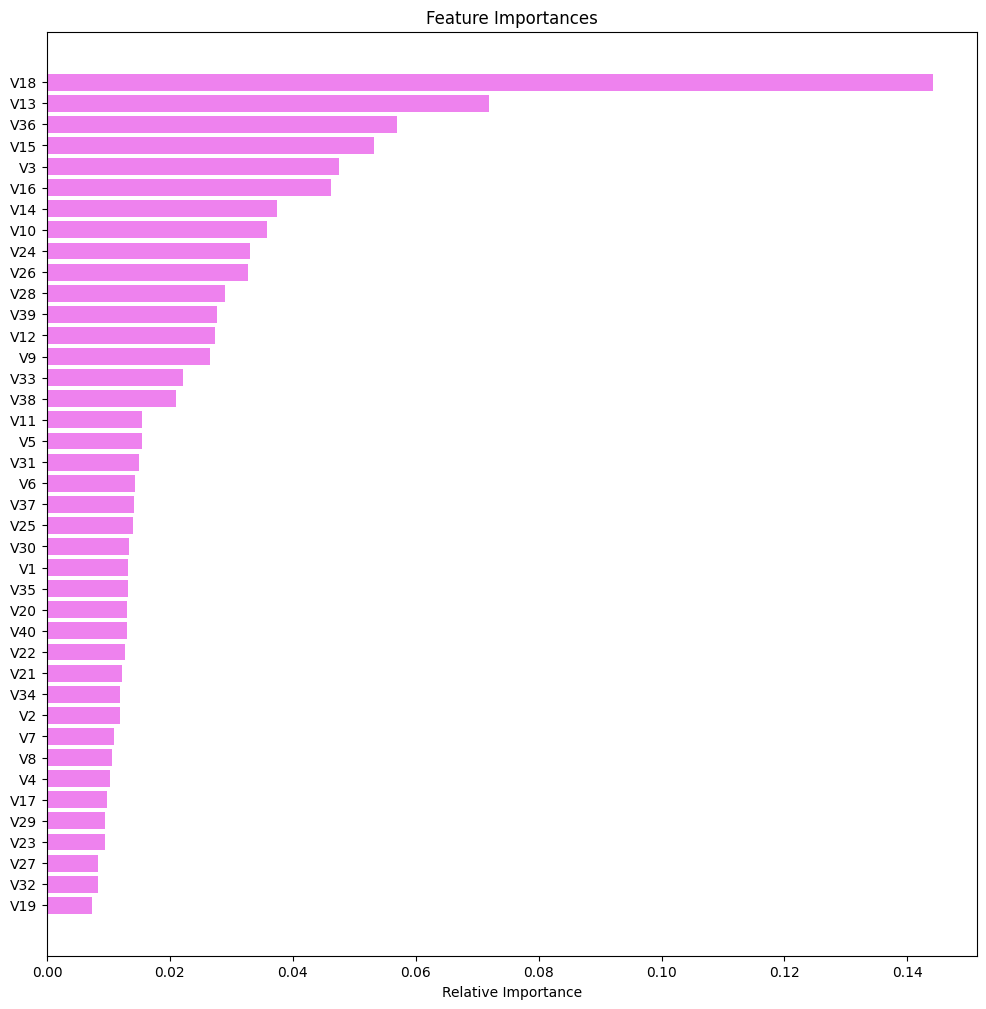

In [ ]:
feature_names = X_test.columns
importances =  xgb_test_over.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Pipelines to build the final model


In [ ]:
# Separating target variable and other variables
X1 = df_train.drop(columns="Target")
Y1 = df_train["Target"]

# We don't need to divide into train and test. Just use the separate test data.

X_test1 = df_test.drop(columns="Target")
y_test1 = df_test['Target']

In [ ]:
# Impute missing values
imputer = SimpleImputer(strategy="median")
X1_imputed = imputer.fit_transform(X1)

In [ ]:
# Oversample the data
smote_pipeline = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_over1, y_over1 = smote_pipeline.fit_resample(X1_imputed, Y1)

In [ ]:
#set parameters on the selected model
xgb_final = XGBClassifier(
    n_estimators = 200,
    scale_pos_weight = 10,
    learning_rate = 0.2,
    gamma = 0,
    subsample = 0.9,
    random_state = 1
)


In [ ]:
#build the pipeline
Pipeline_model = Pipeline(
    steps=[
        ('XGB', xgb_final)           # Train the XGBoost model
    ]
)

In [ ]:
#Fit the final model
Pipeline_model.fit(X_over1, y_over1)

Pipeline(steps=[('XGB',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=1, ...))])

In [ ]:
#check the performance on test set
Pipeline_model_test_score = model_performance_classification_sklearn(Pipeline_model,X_test,y_test)
Pipeline_model_test_score

,Accuracy,Recall,Precision,F1
0,0.982,0.840,0.837,0.839


# Business Insights and Conclusions

Our project clearly states that we want to **maximize recall** in order to minimize fales negatives.

We need to predict failures and there were very few in the training data - roughly 6 percent of the total, so we have to deal with a class imbalance when building our models. Several models did very well on the test and validation sets, but a few were standouts. My final choice was based on high recall and overall balanced performance.

**XGBoost (Tuned with Oversampled Data):**
This was my choice for the final model.

*   It had high accuracy (0.98875, 0.9845) on the validation set.

*   Strong recall and precision, indicating both fewer false negatives and fewer false positives.

*  The F1 score is also very high. The model is well balanced and also did well on the original data without any over-sampling or under-sampling.

*  **The final model scored 0.982 on Accurancy, 0.840 on recall, 0.837 on precision and 0.839 on the unseen Test data.**

**Random Forest (Tuned with Oversampled Data):**

*  Accuracy of 0.98825, precision of 0.9375, and a good balance between recall and precision on the validation set.

*  Strong overall F1 score (0.8924).

**Bagging Classifier (Tuned with Oversampled Data):**

*  Almost perfect scores across all metrics, with 0.985 accuracy, 0.893 precision, and an excellent F1 score (0.8648) on the validation set.

*  Recall is also high at 0.838, so this model is excellent in all aspects, but XGBoost had a slight edge in recall.

**Feature Importances and Additional Recommendations:**

According to our model V18, V13, V36, V15 and V3 are the top 5 features contributing to failure, so the company will want to focus on those.

Additionally, I would also recommend that if the company continues to try to run machine learning models on the data, that they try to get more samples of failure data so that the training set is a little more balanced.




***